### Load Libraries and Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATASET_PATH = Path("../../dataset/mesogeos_wildfire_dataset.csv")

df = pd.read_csv(DATASET_PATH)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (11305, 32)


,date,latitude,longitude,temperature_c,dew_point_c,relative_humidity,wind_speed,wind_direction,rainfall_mm,surface_pressure,...,lc_grassland,lc_settlement,lc_shrubland,lc_sparse_vegetation,lc_water_bodies,lc_wetland,burned_area_ha,year,month,day_of_year
0,2006-08-27,38.123648,-7.819233,36.419031,15.989252,22.510025,3.511700,329.388733,0.000000,99694.617188,...,0.0,0.0,0.000000,0.0,0.0,0.0,40.0,2006,8,239
1,2006-08-11,42.000202,0.447392,27.559045,7.369226,16.027991,6.567619,296.081879,0.004796,93547.523438,...,0.0,0.0,0.192824,0.0,0.0,0.0,1390.0,2006,8,223
2,2006-07-11,41.617581,-8.524061,34.471796,20.400690,35.828364,2.905688,345.955994,0.550396,99709.054688,...,0.0,0.0,0.000000,0.0,0.0,0.0,173.0,2006,7,192
3,2006-09-07,41.557167,-7.567509,30.666193,12.939386,28.009099,2.133366,313.057190,2.396404,93731.859375,...,0.0,0.0,0.000000,0.0,0.0,0.0,220.0,2006,9,250
4,2006-09-08,41.547098,-6.248474,31.690332,14.382166,22.408468,3.914824,288.407166,0.974770,93459.937500,...,0.0,0.0,0.000000,0.0,0.0,0.0,76.0,2006,9,251


### Inspect the dataset structur

In [3]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

df.info()

Rows: 11305
Columns: 32
<class 'pandas.DataFrame'>
RangeIndex: 11305 entries, 0 to 11304
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  11305 non-null  str    
 1   latitude              11305 non-null  float64
 2   longitude             11305 non-null  float64
 3   temperature_c         9844 non-null   float64
 4   dew_point_c           9844 non-null   float64
 5   relative_humidity     9844 non-null   float64
 6   wind_speed            9844 non-null   float64
 7   wind_direction        10891 non-null  float64
 8   rainfall_mm           9844 non-null   float64
 9   surface_pressure      9844 non-null   float64
 10  solar_radiation       9844 non-null   float64
 11  ndvi                  11265 non-null  float64
 12  lai                   11120 non-null  float64
 13  soil_moisture         10171 non-null  float64
 14  elevation             11305 non-null  float64
 15  slope_

### Feature Inventory

In [4]:
feature_inventory = pd.DataFrame({
    "feature": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing": df.isna().sum().values,
    "missing_%": (df.isna().mean() * 100).round(2).values,
    "unique_values": df.nunique().values
})

display(feature_inventory)

,feature,dtype,missing,missing_%,unique_values
0,date,str,0,0.00,2819
1,latitude,float64,0,0.00,1347
2,longitude,float64,0,0.00,3431
3,temperature_c,float64,1461,12.92,9780
4,dew_point_c,float64,1461,12.92,9773
5,relative_humidity,float64,1461,12.92,9838
6,wind_speed,float64,1461,12.92,9840
7,wind_direction,float64,414,3.66,10883
8,rainfall_mm,float64,1461,12.92,5239
9,surface_pressure,float64,1461,12.92,9820


## Interpretation — Feature Inventory

The Mesogeos wildfire dataset contains **11,305 observations and 32 variables**.

The dataset contains meteorological, environmental, terrain, land-cover, geographic, and temporal variables that can potentially contribute to wildfire burned-area prediction.

Several meteorological variables, including temperature, dew point, relative humidity, wind speed, rainfall, surface pressure, and solar radiation, contain approximately **12.92% missing observations**. Soil moisture contains approximately **10.03% missing observations**, while LAI, NDVI, and population have considerably smaller amounts of missing data.

Importantly, the target variable `burned_area_ha` contains **no missing values**, meaning that all extracted wildfire records have a known burned-area value.

The land-cover variables contain continuous values between 0 and 1 and therefore appear to represent the proportion or fraction of the corresponding land-cover type within the sampled area rather than simple categorical classes.

The year variable contains 17 distinct years, while the month and day-of-year variables represent temporal information that can later be used for seasonal feature engineering.

At this stage, no observations or variables are removed. The missing values and feature distributions will be investigated further before a preprocessing strategy is selected.

### Investigate Missing Values

In [5]:
weather_cols = [
    "temperature_c",
    "dew_point_c",
    "relative_humidity",
    "wind_speed",
    "wind_direction",
    "rainfall_mm",
    "surface_pressure",
    "solar_radiation"
]

print("Missing weather values by year:")

display(
    df.groupby("year")[weather_cols]
      .apply(lambda x: x.isna().sum())
)

print("\nMissing weather values by month:")

display(
    df.groupby("month")[weather_cols]
      .apply(lambda x: x.isna().sum())
)

Missing weather values by year:


,temperature_c,dew_point_c,relative_humidity,wind_speed,wind_direction,rainfall_mm,surface_pressure,solar_radiation
year,,,,,,,,
2006,44,44,44,44,12,44,44,44
2007,82,82,82,82,33,82,82,82
2008,53,53,53,53,8,53,53,53
2009,62,62,62,62,22,62,62,62
2010,47,47,47,47,13,47,47,47
2011,103,103,103,103,26,103,103,103
2012,146,146,146,146,41,146,146,146
2013,46,46,46,46,14,46,46,46
2014,41,41,41,41,10,41,41,41



Missing weather values by month:


,temperature_c,dew_point_c,relative_humidity,wind_speed,wind_direction,rainfall_mm,surface_pressure,solar_radiation
month,,,,,,,,
1,11,11,11,11,6,11,11,11
2,26,26,26,26,6,26,26,26
3,30,30,30,30,8,30,30,30
4,18,18,18,18,6,18,18,18
5,34,34,34,34,12,34,34,34
6,154,154,154,154,37,154,154,154
7,436,436,436,436,127,436,436,436
8,483,483,483,483,139,483,483,483
9,191,191,191,191,51,191,191,191


## Interpretation — Missing Weather Values

The investigation shows that missing meteorological observations occur throughout the complete 2006–2022 study period rather than being restricted to a single year.

The missing values are also concentrated in the summer months, particularly July and August. However, these months contain substantially more wildfire records than the other months. Therefore, raw missing-value counts alone cannot determine whether the probability of missing data is actually higher during the summer fire season.

The missingness pattern will therefore be evaluated using percentages relative to the number of observations in each year and month.

An additional observation is that `wind_direction` has substantially fewer missing values than the other main meteorological variables. This suggests that different variables may have different missing-data patterns.

At this stage, no missing values are removed or imputed. The missing-data mechanism will be investigated further before selecting an appropriate preprocessing strategy.

### Calculate the missing-data percentages

In [6]:
# MISSING WEATHER PERCENTAGE BY YEAR

year_total = df.groupby("year").size()

year_missing_percent = (
    df.groupby("year")[weather_cols]
      .apply(lambda x: x.isna().mean() * 100)
)

print("Missing weather percentage by year:")
display(year_missing_percent.round(2))

# MISSING WEATHER PERCENTAGE BY MONTH

month_total = df.groupby("month").size()

month_missing_percent = (
    df.groupby("month")[weather_cols]
      .apply(lambda x: x.isna().mean() * 100)
)

print("\nMissing weather percentage by month:")
display(month_missing_percent.round(2))

Missing weather percentage by year:


,temperature_c,dew_point_c,relative_humidity,wind_speed,wind_direction,rainfall_mm,surface_pressure,solar_radiation
year,,,,,,,,
2006,20.56,20.56,20.56,20.56,5.61,20.56,20.56,20.56
2007,13.60,13.60,13.60,13.60,5.47,13.60,13.60,13.60
2008,17.91,17.91,17.91,17.91,2.70,17.91,17.91,17.91
2009,13.60,13.60,13.60,13.60,4.82,13.60,13.60,13.60
2010,11.19,11.19,11.19,11.19,3.10,11.19,11.19,11.19
2011,13.19,13.19,13.19,13.19,3.33,13.19,13.19,13.19
2012,13.96,13.96,13.96,13.96,3.92,13.96,13.96,13.96
2013,10.85,10.85,10.85,10.85,3.30,10.85,10.85,10.85
2014,12.81,12.81,12.81,12.81,3.12,12.81,12.81,12.81



Missing weather percentage by month:


,temperature_c,dew_point_c,relative_humidity,wind_speed,wind_direction,rainfall_mm,surface_pressure,solar_radiation
month,,,,,,,,
1,7.01,7.01,7.01,7.01,3.82,7.01,7.01,7.01
2,6.93,6.93,6.93,6.93,1.60,6.93,6.93,6.93
3,2.93,2.93,2.93,2.93,0.78,2.93,2.93,2.93
4,4.38,4.38,4.38,4.38,1.46,4.38,4.38,4.38
5,17.17,17.17,17.17,17.17,6.06,17.17,17.17,17.17
6,21.78,21.78,21.78,21.78,5.23,21.78,21.78,21.78
7,15.79,15.79,15.79,15.79,4.60,15.79,15.79,15.79
8,13.47,13.47,13.47,13.47,3.88,13.47,13.47,13.47
9,14.55,14.55,14.55,14.55,3.88,14.55,14.55,14.55


## Interpretation — Missing-Data Percentages

The percentage-based analysis shows that missing meteorological observations are distributed across the study period and vary by both year and month.

For the main meteorological variables, annual missingness ranges from approximately 9% to 21%. The highest missing rate occurs in 2006 (20.56%), while 2019 has the lowest rate (9.01%). The `wind_direction` variable has considerably lower missingness, generally remaining below approximately 6%.

Monthly missingness also varies substantially. June has the highest missing rate at approximately 21.78%, followed by May at 17.17%. March has the lowest rate at approximately 2.93%.

Therefore, the missing values do not appear to be uniformly distributed across time. However, the dataset still contains a large number of valid observations and the target variable `burned_area_ha` has no missing values.

The weather variables will therefore be retained. Missing values will be handled during the preprocessing stage using an appropriate imputation strategy. The imputation parameters will be learned only from the training data to prevent data leakage.

No rows are removed at this stage.

### Duplicate Investigation

In [7]:
# Check for completely duplicated records
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    print("\nDuplicate records:")
    display(df[df.duplicated(keep=False)].sort_values(
        by=["date", "latitude", "longitude"]
    ))
else:
    print("No duplicate records found.")

Duplicate rows: 2

Duplicate records:


,date,latitude,longitude,temperature_c,dew_point_c,relative_humidity,wind_speed,wind_direction,rainfall_mm,surface_pressure,...,lc_grassland,lc_settlement,lc_shrubland,lc_sparse_vegetation,lc_water_bodies,lc_wetland,burned_area_ha,year,month,day_of_year
7716,2019-12-30,43.178272,-6.399508,11.799799,4.803339,42.646006,2.036749,181.545166,0.000010,93030.632812,...,0.350848,0.0,0.0,0.0,0.0,0.0,126.0,2019,12,364
8172,2019-12-30,43.178272,-6.399508,11.799799,4.803339,42.646006,2.036749,181.545166,0.000010,93030.632812,...,0.350848,0.0,0.0,0.0,0.0,0.0,126.0,2019,12,364
10087,2021-12-28,43.178272,-6.389439,13.648492,9.709192,73.061812,3.787528,205.027756,0.450703,92098.796875,...,0.035176,0.0,0.0,0.0,0.0,0.0,95.0,2021,12,362
10103,2021-12-28,43.178272,-6.389439,13.648492,9.709192,73.061812,3.787528,205.027756,0.450703,92098.796875,...,0.035176,0.0,0.0,0.0,0.0,0.0,95.0,2021,12,362


## Interpretation — Duplicate Records

The dataset contains **2 exact duplicate records**. Because each duplicate appears twice, four rows are displayed when both copies are shown using `keep=False`.

The duplicated observations correspond to wildfire records dated 2019-12-30 and 2021-12-28. The duplicated rows contain identical values across all 32 columns, including their geographic coordinates, environmental conditions, land-cover information, and burned-area measurements.

These records do not appear to represent separate wildfire events. Keeping duplicate observations could cause certain samples to receive additional weight during model training and may contribute to biased model evaluation, particularly if duplicate observations are distributed between training and testing sets.

Therefore, one copy of each exact duplicate will be removed during the preprocessing stage. The original investigation dataset will remain unchanged at this stage.

### Investigate the target variable

In [8]:
# TARGET VARIABLE — BASIC STATISTICS

target = "burned_area_ha"

print("Target variable:", target)
print("Number of observations:", df[target].count())
print("Missing values:", df[target].isna().sum())

print("\nDescriptive statistics:")
display(df[target].describe())

print("\nSelected percentiles:")
display(
    df[target].quantile(
        [0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 1.00]
    ).rename("burned_area_ha")
)

Target variable: burned_area_ha
Number of observations: 11305
Missing values: 0

Descriptive statistics:


count     11305.000000
mean        489.286953
std        2093.071924
min          30.000000
25%          66.000000
50%         131.000000
75%         335.000000
max      107602.000000
Name: burned_area_ha, dtype: float64


Selected percentiles:


0.500       131.00
0.750       335.00
0.900       868.60
0.950      1665.00
0.990      5900.20
0.995     10197.08
1.000    107602.00
Name: burned_area_ha, dtype: float64

## Interpretation — Target Variable

The target variable `burned_area_ha` contains 11,305 valid wildfire observations and has no missing values.

The distribution is strongly right-skewed. The median burned area is 131 hectares, while the mean is substantially higher at approximately 489 hectares. This difference indicates that a relatively small number of very large wildfire events have a strong influence on the mean.

The percentile analysis further demonstrates the long-tailed nature of the target. Approximately 90% of observations have burned areas below 868.6 hectares, while the 99th percentile is 5,900.2 hectares. However, the maximum recorded burned area is 107,602 hectares.

This indicates the presence of a small number of extreme wildfire events. These observations should not automatically be treated as errors because very large wildfires are physically possible and may represent genuine events.

The strong right-skewness is important for regression modelling because extreme target values can disproportionately influence model training and evaluation. The distribution will therefore be visualized and compared with a logarithmic transformation before deciding how the target should be handled during model development.

### Raw Target Distribution

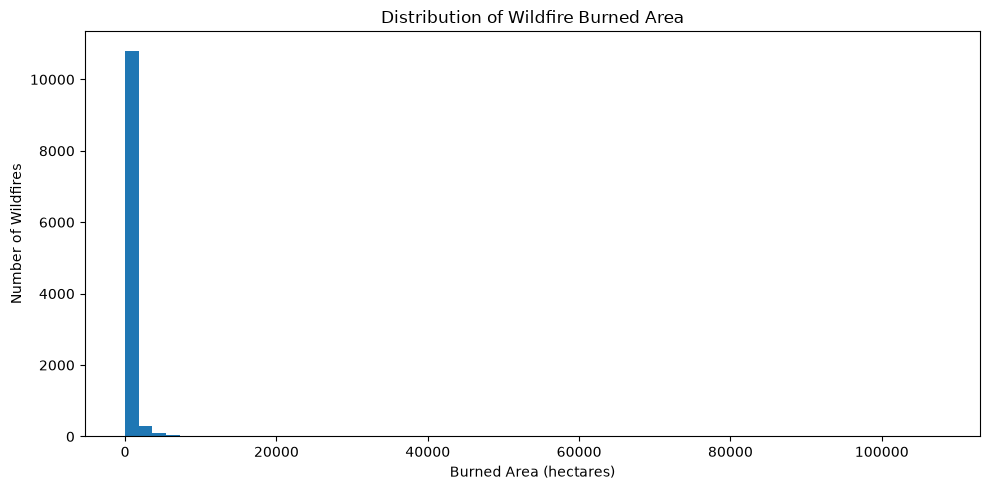

In [13]:
plt.figure(figsize=(10, 5))

plt.hist(df["burned_area_ha"], bins=60)

plt.title("Distribution of Wildfire Burned Area")
plt.xlabel("Burned Area (hectares)")
plt.ylabel("Number of Wildfires")

plt.tight_layout()
plt.show()

## Interpretation — Raw Target Distribution

The histogram confirms that `burned_area_ha` has a strongly right-skewed distribution.

Most wildfire observations are concentrated at relatively small burned-area values, while a small number of observations represent extremely large wildfire events. These extreme observations extend the distribution over a very wide range and make the majority of records difficult to distinguish on the raw scale.

This pattern is consistent with the percentile analysis, where the median burned area is 131 hectares while the maximum reaches 107,602 hectares.

The extreme observations should not automatically be considered errors because they may represent genuine large-scale wildfire events. However, their strong influence on the target distribution may make regression modelling more difficult.

A logarithmic transformation will therefore be investigated as a way of compressing the extreme values and producing a more balanced target distribution for model training.

### Log-transform the target

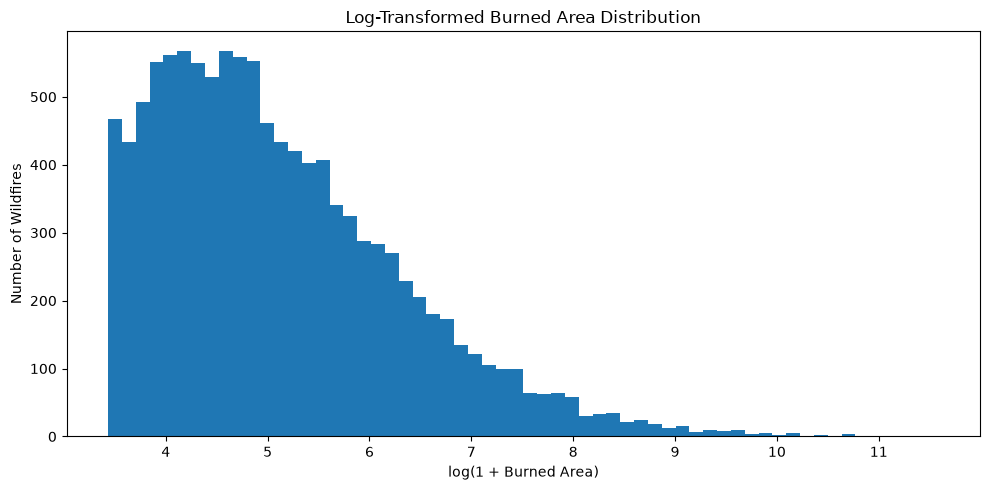

In [14]:
# Log-transformed burned-area distribution

log_burned_area = np.log1p(df["burned_area_ha"])

plt.figure(figsize=(10, 5))

plt.hist(log_burned_area, bins=60)

plt.title("Log-Transformed Burned Area Distribution")
plt.xlabel("log(1 + Burned Area)")
plt.ylabel("Number of Wildfires")

plt.tight_layout()
plt.show()

## Interpretation — Log-Transformed Target

The logarithmic transformation substantially reduces the extreme right-skewness observed in the original `burned_area_ha` distribution.

Using `log1p(burned_area_ha)` compresses very large burned-area values while preserving the ordering of wildfire events. The transformed distribution still has a right tail, but the observations are distributed across the available range much more evenly than in the raw target distribution.

This transformation is therefore a strong candidate for regression model training. It can reduce the disproportionate influence of extremely large wildfire events and may improve the stability of model fitting.

The original burned-area values will still be retained for interpretation and final reporting. If the transformed target is used for modelling, predictions will be converted back to hectares using the inverse transformation `expm1()` so that the final application can report burned area in the original unit.

The decision to use the transformed target will ultimately be validated by comparing model performance using appropriate regression metrics on unseen test data.

### Burned Area by Year

In [15]:
year_burned_area = (
    df.groupby("year")["burned_area_ha"]
      .agg(
          fires="count",
          mean="mean",
          median="median",
          total="sum",
          maximum="max"
      )
      .round(2)
)

display(year_burned_area)

,fires,mean,median,total,maximum
year,,,,,
2006,214,428.07,162.0,91607.0,6837.0
2007,603,893.72,225.0,538911.0,45809.0
2008,296,426.14,158.5,126138.0,16407.0
2009,456,548.53,161.0,250128.0,20521.0
2010,420,382.07,139.0,160470.0,10804.0
2011,781,319.87,131.0,249819.0,6245.0
2012,1046,614.51,192.0,642775.0,32424.0
2013,424,454.92,147.5,192885.0,15015.0
2014,320,401.59,165.0,128509.0,6327.0


### Verify the target maximum

In [16]:
print("Overall maximum:", df["burned_area_ha"].max())

print("\nRows with burned area > 100,000 ha:")
display(
    df[df["burned_area_ha"] > 100000][
        ["date", "latitude", "longitude", "burned_area_ha", "year", "month"]
    ].sort_values("burned_area_ha", ascending=False)
)

Overall maximum: 107602.0

Rows with burned area > 100,000 ha:


,date,latitude,longitude,burned_area_ha,year,month
6183,2017-10-05,40.187787,-7.889716,107602.0,2017,10


### Recalculate the yearly table

In [17]:
year_burned_area = (
    df.groupby("year")["burned_area_ha"]
      .agg(
          fires="count",
          mean="mean",
          median="median",
          total="sum",
          maximum="max"
      )
)

year_burned_area["mean"] = year_burned_area["mean"].round(2)
year_burned_area["median"] = year_burned_area["median"].round(2)
year_burned_area["total"] = year_burned_area["total"].round(2)
year_burned_area["maximum"] = year_burned_area["maximum"].round(2)

display(year_burned_area)

,fires,mean,median,total,maximum
year,,,,,
2006,214,428.07,162.0,91607.0,6837.0
2007,603,893.72,225.0,538911.0,45809.0
2008,296,426.14,158.5,126138.0,16407.0
2009,456,548.53,161.0,250128.0,20521.0
2010,420,382.07,139.0,160470.0,10804.0
2011,781,319.87,131.0,249819.0,6245.0
2012,1046,614.51,192.0,642775.0,32424.0
2013,424,454.92,147.5,192885.0,15015.0
2014,320,401.59,165.0,128509.0,6327.0


In [18]:
print("Overall maximum:", df["burned_area_ha"].max())
print(
    "Maximum yearly value:",
    year_burned_area["maximum"].max()
)

Overall maximum: 107602.0
Maximum yearly value: 107602.0


## Interpretation — Burned Area by Year

The yearly analysis shows substantial variation in wildfire activity between 2006 and 2022. The number of wildfire records varies from 214 observations in 2006 to 1,321 observations in 2017.

The mean burned area is consistently higher than the median in most years, confirming that the target variable is strongly right-skewed and that relatively large wildfire events can substantially influence annual averages.

The year 2017 contains the largest recorded wildfire event in the dataset, with a burned area of 107,602 hectares. However, the median burned area for the same year is only 128 hectares. This demonstrates that extreme wildfire events can have a very large influence on yearly statistics without representing the typical wildfire observation.

The yearly results do not indicate a simple monotonic increase or decrease in wildfire activity over the study period. Instead, both the number of records and burned-area statistics fluctuate considerably between years.

These temporal variations are important for model development. Year and seasonal information may contain useful predictive information, while the strong influence of extreme events supports further consideration of a logarithmic target transformation during regression modelling.

### Burned Area by Month

In [19]:
month_burned_area = (
    df.groupby("month")["burned_area_ha"]
      .agg(
          fires="count",
          mean="mean",
          median="median",
          total="sum",
          maximum="max"
      )
)

month_burned_area["mean"] = month_burned_area["mean"].round(2)
month_burned_area["median"] = month_burned_area["median"].round(2)
month_burned_area["total"] = month_burned_area["total"].round(2)
month_burned_area["maximum"] = month_burned_area["maximum"].round(2)

display(month_burned_area)

,fires,mean,median,total,maximum
month,,,,,
1,157,300.30,99.0,47147.0,6060.0
2,375,244.76,89.0,91785.0,5842.0
3,1025,243.35,105.0,249433.0,6700.0
4,411,280.00,96.0,115081.0,14160.0
5,198,251.67,82.5,49830.0,7005.0
6,707,595.30,140.0,420880.0,46769.0
7,2761,619.56,182.0,1710596.0,54769.0
8,3587,573.64,145.0,2057641.0,51245.0
9,1313,283.33,113.0,372015.0,15536.0


## Interpretation — Burned Area by Month

The monthly analysis demonstrates a strong seasonal pattern in wildfire activity. July and August contain the

### Visualize wildfire frequency by month

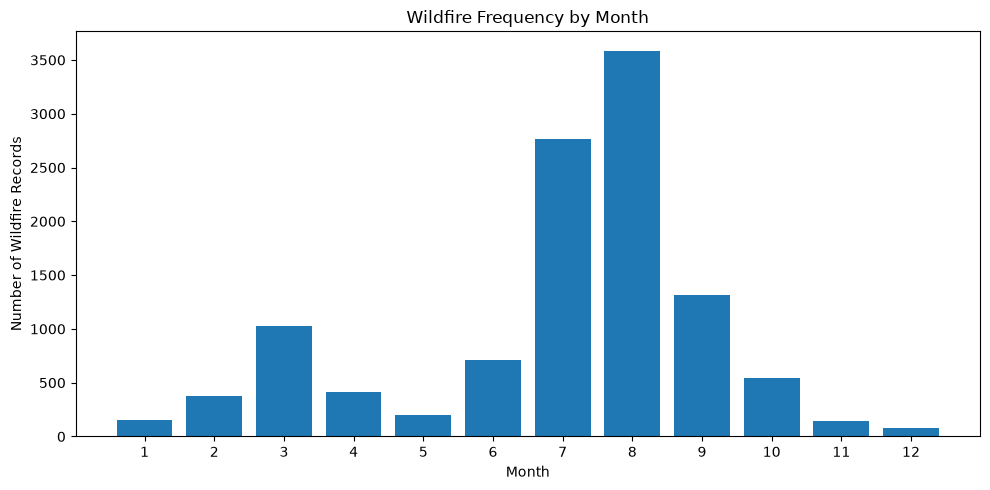

In [21]:
# WILDFIRE FREQUENCY BY MONTH

plt.figure(figsize=(10, 5))

plt.bar(
    month_burned_area.index,
    month_burned_area["fires"]
)

plt.title("Wildfire Frequency by Month")
plt.xlabel("Month")
plt.ylabel("Number of Wildfire Records")

plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

## Interpretation — Wildfire Frequency by Month

The monthly frequency visualization confirms a strong seasonal concentration of wildfire records.

August has the highest number of wildfire observations, followed by July and September. Together, these summer months account for a substantial proportion of the dataset. In contrast, wildfire records are considerably less frequent during late autumn and winter, particularly November, December, and January.

This seasonal pattern indicates that month and related temporal features may provide useful information for burned-area prediction. However, wildfire frequency should not be confused with wildfire severity. A month with fewer wildfire records can still contain exceptionally large individual fires.

Therefore, both fire frequency and burned-area severity will be considered separately during the remaining exploratory analysis.

### Visualize burned-area severity by month

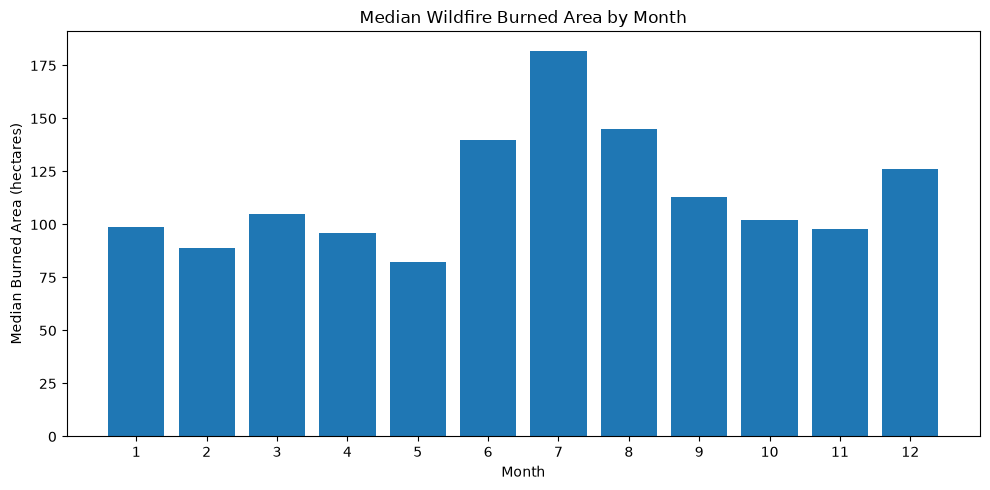

In [22]:
# MEDIAN BURNED AREA BY MONTH

plt.figure(figsize=(10, 5))

plt.bar(
    month_burned_area.index,
    month_burned_area["median"]
)

plt.title("Median Wildfire Burned Area by Month")
plt.xlabel("Month")
plt.ylabel("Median Burned Area (hectares)")

plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

## Interpretation — Median Burned Area by Month

The median burned-area analysis provides a more robust measure of typical wildfire severity because the target variable contains extreme large-fire observations.

July has the highest median burned area at approximately 182 hectares, followed by August and June. This indicates that fires occurring during the peak summer period tend to have relatively greater typical burned areas.

May has the lowest median burned area at approximately 82 hectares. The relatively moderate median values in several other months indicate that wildfire severity is not determined by season alone.

An important observation is that October contains the overall maximum fire of 107,602 hectares, despite having a median burned area of only approximately 102 hectares. This demonstrates the extreme right-skewness of the target variable and confirms that a small number of exceptionally large fires can occur outside the months with the highest typical fire severity.

Therefore, month may be useful as a predictive feature, but it should be combined with meteorological, vegetation, terrain, and geographical variables.

### Geographic distribution

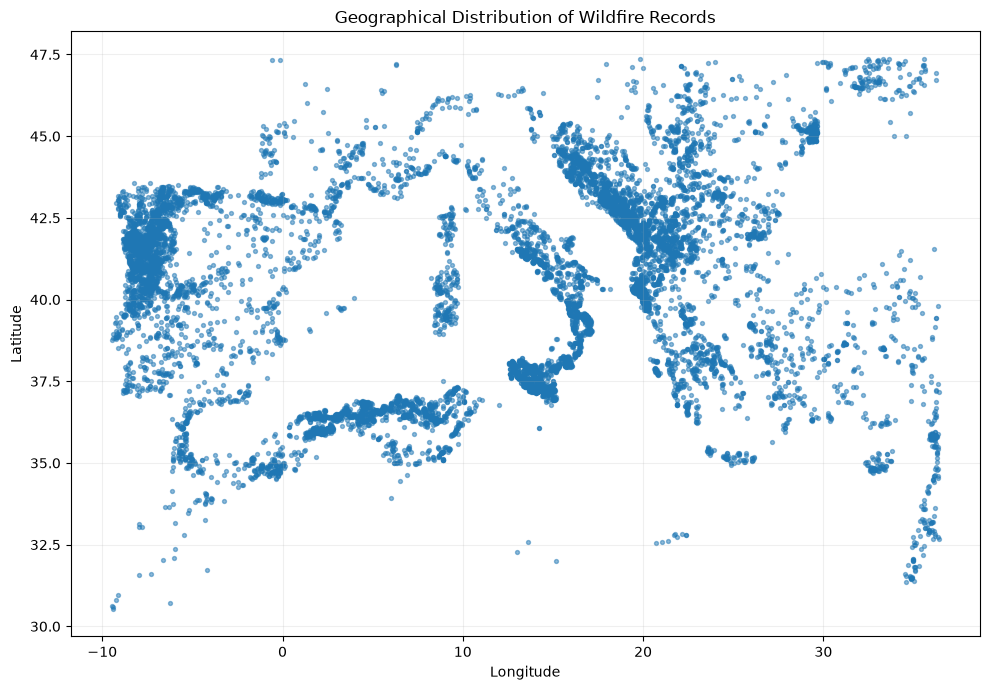

In [23]:
# GEOGRAPHIC DISTRIBUTION OF WILDFIRE RECORDS

plt.figure(figsize=(10, 7))

plt.scatter(
    df["longitude"],
    df["latitude"],
    s=8,
    alpha=0.5
)

plt.title("Geographical Distribution of Wildfire Records")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Interpretation — Geographical Distribution

The geographical distribution shows that wildfire records are spatially clustered rather than uniformly distributed across the study region.

Several areas contain a much higher concentration of observations, while other areas have relatively few records. This indicates that the dataset has a non-uniform spatial sampling pattern.

Latitude and longitude may therefore provide useful information for predicting burned area because wildfire characteristics can vary geographically due to differences in climate, vegetation, terrain, and human influence.

However, the concentration of observations should not be interpreted directly as wildfire risk. A high number of records in a particular region may partly reflect the availability and coverage of wildfire observations rather than a higher inherent probability of fire.

For the machine-learning stage, geographic coordinates will initially be retained as candidate predictive features. Their contribution will later be evaluated using feature importance and model interpretation techniques.

### Burned area by geographic location

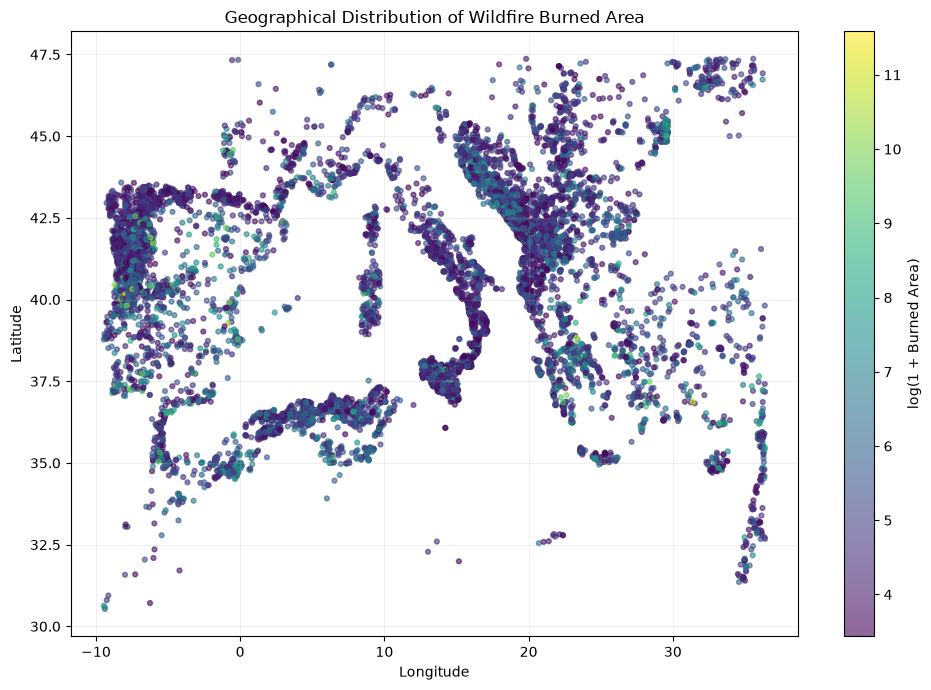

In [24]:
# GEOGRAPHICAL DISTRIBUTION OF BURNED AREA

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    df["longitude"],
    df["latitude"],
    c=np.log1p(df["burned_area_ha"]),
    s=12,
    alpha=0.6
)

plt.colorbar(scatter, label="log(1 + Burned Area)")
plt.title("Geographical Distribution of Wildfire Burned Area")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Interpretation — Geographical Distribution of Burned Area

The geographical distribution of burned area shows that wildfire severity varies across different parts of the study region.

The use of a logarithmic transformation, `log(1 + burned_area_ha)`, improves the visualization because the burned-area target contains extreme values. The resulting map-like scatter plot shows that larger burned-area observations occur across multiple geographical clusters rather than being restricted to a single location.

This suggests that geographical coordinates may contain useful predictive information. Differences in latitude and longitude can indirectly represent variations in climate, vegetation, terrain, land use, and human influence.

However, the spatial concentration of large fires should not be interpreted as direct evidence that a particular location causes larger fires. The observed pattern may also be influenced by the spatial distribution and sampling of the underlying wildfire records.

Therefore, latitude and longitude will be retained as candidate predictive features and their actual contribution will be evaluated during feature analysis and machine-learning model interpretation.

### CORRELATION WITH BURNED AREA

In [25]:
numeric_df = df.select_dtypes(include=np.number)

# Raw target correlation
raw_correlation = (
    numeric_df.corr()["burned_area_ha"]
    .drop("burned_area_ha")
    .sort_values(key=abs, ascending=False)
)

print("=== CORRELATION WITH RAW BURNED AREA ===")
display(raw_correlation.to_frame("correlation"))

=== CORRELATION WITH RAW BURNED AREA ===


,correlation
relative_humidity,-0.110286
temperature_c,0.091220
wind_speed,0.073741
lc_shrubland,0.058861
solar_radiation,0.050311
soil_moisture,-0.049375
lc_agriculture,-0.049080
month,0.033476
day_of_year,0.033349
latitude,-0.032981


## Interpretation — Correlation with Raw Burned Area

The correlation analysis shows that none of the individual predictor variables has a strong linear relationship with burned area.

Relative humidity has the strongest absolute correlation with the target (r ≈ -0.111), followed by temperature (r ≈ 0.091) and wind speed (r ≈ 0.074). The remaining variables have even weaker linear relationships.

The negative relationship between relative humidity and burned area is consistent with the general expectation that drier atmospheric conditions can support more severe fire behavior. Temperature and wind speed show weak positive relationships with burned area.

However, these correlations should not be interpreted as evidence that the corresponding variables are unimportant. Wildfire severity is influenced by multiple interacting environmental, meteorological, vegetation, terrain, and geographical factors.

The extremely right-skewed distribution of burned area also limits the usefulness of raw Pearson correlation. A small number of exceptionally large fires can strongly influence the correlation coefficients.

Therefore, low individual correlations will not be used as the sole criterion for removing features. The dataset will instead be investigated using the log-transformed target, multivariate modelling, feature importance, and model explainability techniques.

### Correlation with Log-Transformed Burned Area

In [26]:
df["log_burned_area"] = np.log1p(df["burned_area_ha"])

numeric_df = df.select_dtypes(include=np.number)

log_correlation = (
    numeric_df.corr()["log_burned_area"]
    .drop("log_burned_area")
    .sort_values(key=abs, ascending=False)
)

print("=== CORRELATION WITH LOG-TRANSFORMED BURNED AREA ===")

display(
    log_correlation.to_frame("correlation")
)

=== CORRELATION WITH LOG-TRANSFORMED BURNED AREA ===


,correlation
burned_area_ha,0.491469
relative_humidity,-0.241519
temperature_c,0.202301
solar_radiation,0.163584
soil_moisture,-0.138108
wind_speed,0.125820
year,-0.125624
roads_distance_km,0.122214
lc_shrubland,0.113473
ndvi,-0.093957


## Interpretation — Correlation with Log-Transformed Burned Area

The correlation analysis was repeated using the logarithmically transformed target, `log(1 + burned_area_ha)`, to reduce the influence of extreme wildfire observations.

The results reveal stronger relationships than those observed using the raw burned-area values.

Relative humidity has the strongest negative correlation with the transformed target (r ≈ -0.242), while temperature has the strongest positive correlation (r ≈ 0.202). Solar radiation (r ≈ 0.164), soil moisture (r ≈ -0.138), and wind speed (r ≈ 0.126) also show relatively stronger relationships.

These results are consistent with the expected influence of fire-weather conditions. Lower humidity and higher temperature can create drier conditions that are more favorable for wildfire development and spread. Higher solar radiation may also be associated with increased drying of vegetation and surface conditions.

The correlations remain relatively weak overall, demonstrating that wildfire burned area is a complex outcome that cannot be explained by a single environmental variable.

The transformed target provides a more informative representation of the relationships and will therefore be considered during model development. However, correlation measures only linear relationships, so nonlinear machine-learning models will also be evaluated.

The `burned_area_ha` correlation shown in the table itself is excluded from interpretation because it represents the mathematical relationship between the original target and its own log-transformed version.

### Correlation Heatmap

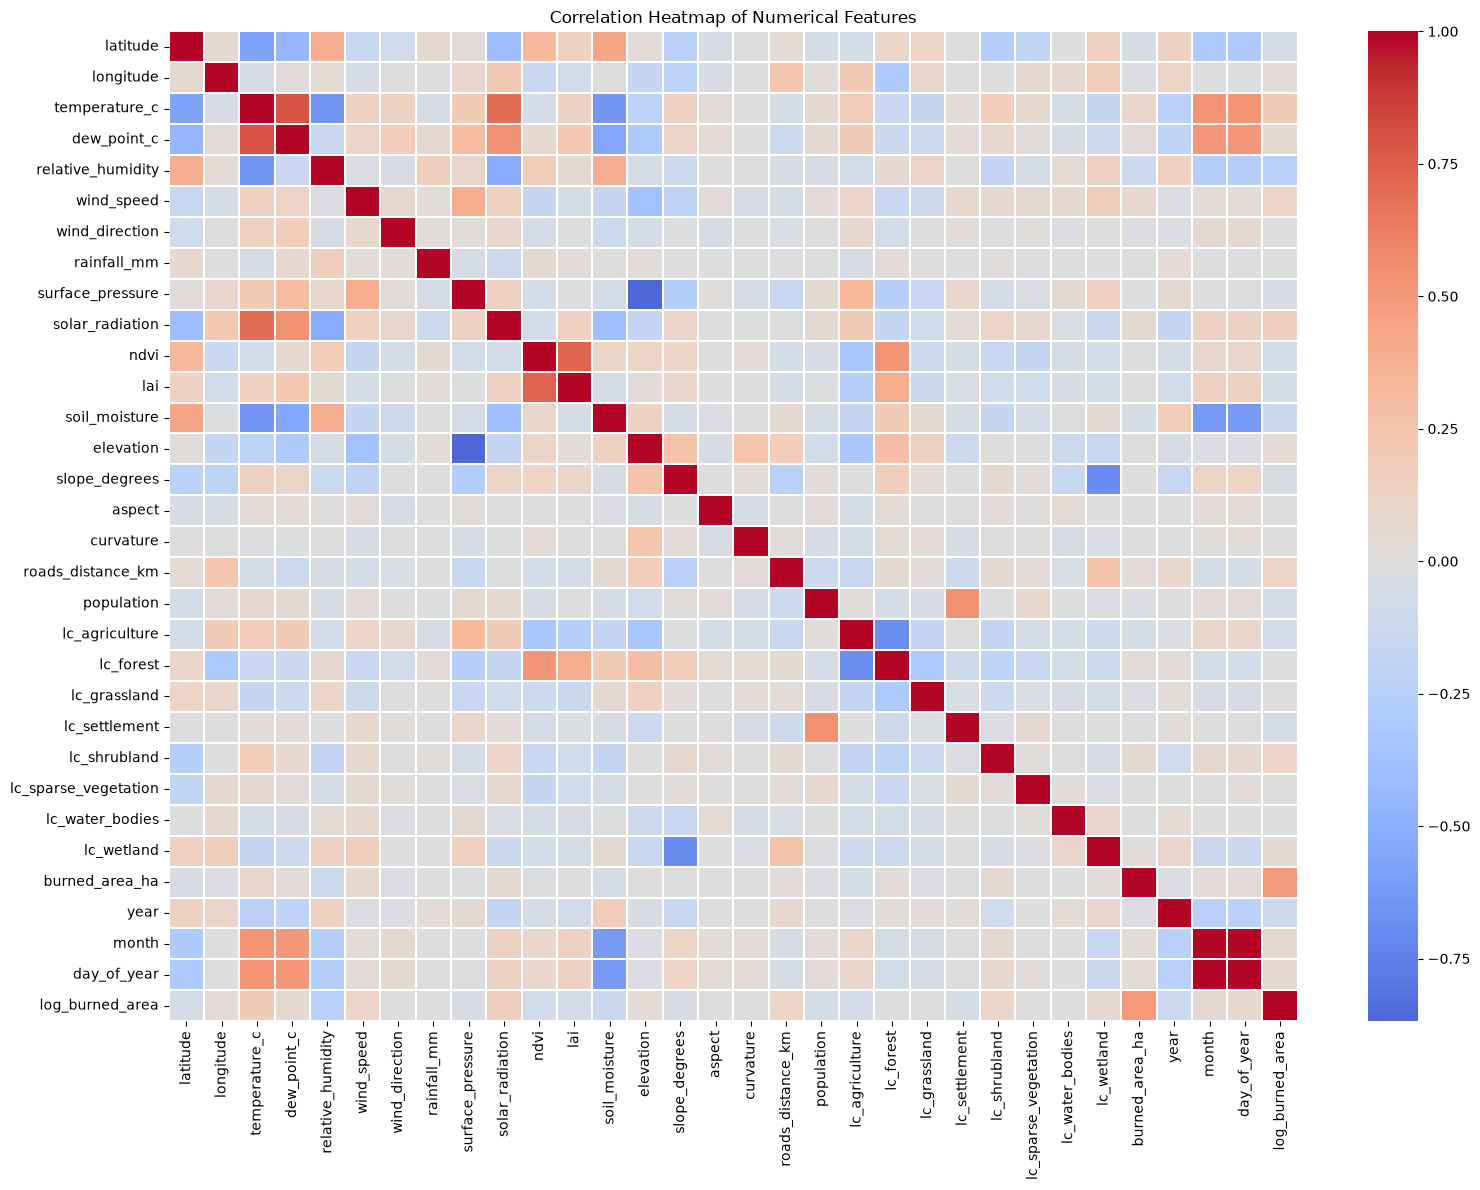

In [27]:
import seaborn as sns

correlation_matrix = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

## Interpretation — Correlation Heatmap

The correlation heatmap was examined to identify relationships between numerical variables and potential multicollinearity among predictor features.

A relatively strong positive relationship is observed between temperature and dew-point temperature. Temperature also shows a positive relationship with solar radiation. These relationships are physically reasonable because atmospheric and solar conditions are interconnected.

NDVI and LAI also show a positive relationship because both variables describe aspects of vegetation condition.

The land-cover variables exhibit relationships with one another because they represent the composition of the same geographical areas. These relationships are expected and do not automatically indicate problematic redundancy.

A particularly strong relationship is observed between month and day-of-year because both variables represent seasonal timing. This will be considered during feature engineering to avoid unnecessary duplication of seasonal information.

Overall, the heatmap does not indicate severe multicollinearity across the majority of predictor variables. Therefore, no features will be removed solely on the basis of this heatmap. Feature selection will instead be performed using statistical analysis, model-based feature importance, and model performance.

### Missing valu Pattern

In [28]:
missing_columns = df.columns[df.isna().any()].tolist()

missing_pattern = (
    df[missing_columns]
    .isna()
    .astype(int)
)

pattern_counts = (
    missing_pattern
    .value_counts()
    .reset_index(name="records")
)

print("Number of unique missing-value patterns:", len(pattern_counts))

display(pattern_counts.head(15))

Number of unique missing-value patterns: 28


,temperature_c,dew_point_c,relative_humidity,wind_speed,wind_direction,rainfall_mm,surface_pressure,solar_radiation,ndvi,lai,soil_moisture,population,records
0,0,0,0,0,0,0,0,0,0,0,0,0,8762
1,0,0,0,0,0,0,0,0,0,0,1,0,949
2,1,1,1,1,0,1,1,1,0,0,0,0,900
3,1,1,1,1,1,1,1,1,0,0,0,0,348
4,1,1,1,1,0,1,1,1,0,0,1,0,107
5,0,0,0,0,0,0,0,0,0,1,0,0,95
6,1,1,1,1,1,1,1,1,0,0,1,0,40
7,1,1,1,1,0,1,1,1,0,1,0,0,25
8,0,0,0,0,0,0,0,0,1,1,1,0,21
9,1,1,1,1,1,1,1,1,0,1,0,0,11


## Interpretation — Missing-Value Patterns

The missing-value pattern analysis identified 28 distinct combinations of missing features.

A large majority of the dataset (8,762 records) contains complete observations. However, several groups of records contain missing meteorological variables simultaneously.

The most notable pattern consists of records where temperature, dew-point temperature, relative humidity, wind speed, rainfall, surface pressure, and solar radiation are missing together. This indicates that the missing meteorological values are likely related to a common data-availability or source-data issue rather than independent random missing values.

Soil moisture also has a substantial number of missing observations, while LAI, NDVI, and population have comparatively small amounts of missing data.

Because the missing values occur in meaningful groups, simply deleting every incomplete row would result in unnecessary data loss. Similarly, replacing all missing values with zero would be inappropriate because zero does not represent a realistic missing measurement for most meteorological variables.

Therefore, missing-value handling will be treated as an explicit preprocessing stage. Different strategies will be considered according to the feature type and the structure of the missingness.

In [29]:
weather_columns = [
    "temperature_c",
    "dew_point_c",
    "relative_humidity",
    "wind_speed",
    "rainfall_mm",
    "surface_pressure",
    "solar_radiation"
]

# Identify records where all major weather variables are missing
weather_missing = df[weather_columns].isna().all(axis=1)

weather_missing_df = df[weather_missing].copy()

print("Records with all major weather variables missing:",
      len(weather_missing_df))

print("\nMissing records by year:")
display(weather_missing_df["year"].value_counts().sort_index())

print("\nMissing records by month:")
display(weather_missing_df["month"].value_counts().sort_index())

Records with all major weather variables missing: 1461

Missing records by year:


year
2006     44
2007     82
2008     53
2009     62
2010     47
2011    103
2012    146
2013     46
2014     41
2015     58
2016     86
2017    179
2018     49
2019     85
2020    118
2021    111
2022    151
Name: count, dtype: int64


Missing records by month:


month
1      11
2      26
3      30
4      18
5      34
6     154
7     436
8     483
9     191
10     55
11     18
12      5
Name: count, dtype: int64

## Interpretation — Temporal Pattern of Missing Weather Data

The 1,461 records with all major meteorological variables missing are distributed across the entire 2006–2022 study period rather than being isolated to a single year.

However, the missing observations are strongly concentrated during the wildfire season. August contains the largest number of records with missing weather data (483), followed by July (436), September (191), and June (154).

This indicates that the missingness is not completely random and may be associated with the temporal or spatial availability of the underlying meteorological data.

Importantly, these records still contain useful information such as geographic coordinates, date, vegetation characteristics, terrain variables, land-cover information, and the observed burned area. Therefore, removing all incomplete records would unnecessarily reduce the dataset and potentially introduce sampling bias.

The missing meteorological observations will therefore be retained and handled during the preprocessing stage using appropriate imputation methods. The imputation process will be fitted only on the training data to prevent data leakage.

In [30]:
# BURNED AREA: COMPLETE VS MISSING WEATHER RECORDS

weather_missing = df[weather_columns].isna().all(axis=1)

comparison = pd.DataFrame({
    "Weather data status": [
        "Complete weather data",
        "Major weather variables missing"
    ],
    "Records": [
        (~weather_missing).sum(),
        weather_missing.sum()
    ],
    "Mean burned area (ha)": [
        df.loc[~weather_missing, "burned_area_ha"].mean(),
        df.loc[weather_missing, "burned_area_ha"].mean()
    ],
    "Median burned area (ha)": [
        df.loc[~weather_missing, "burned_area_ha"].median(),
        df.loc[weather_missing, "burned_area_ha"].median()
    ],
    "Maximum burned area (ha)": [
        df.loc[~weather_missing, "burned_area_ha"].max(),
        df.loc[weather_missing, "burned_area_ha"].max()
    ]
})

display(comparison)

,Weather data status,Records,Mean burned area (ha),Median burned area (ha),Maximum burned area (ha)
0,Complete weather data,9844,495.861337,132.0,107602.0
1,Major weather variables missing,1461,444.989733,124.0,54769.0


## Interpretation — Burned Area Comparison for Missing Weather Records

The burned-area distributions were compared between records with complete meteorological information and records where the major weather variables are missing.

The two groups have relatively similar typical wildfire sizes. The median burned area is 132 hectares for records with complete weather information and 124 hectares for records with missing weather information.

The mean burned areas are also reasonably similar, although both are strongly influenced by extreme wildfire observations. The maximum burned area is lower in the missing-weather group, but this does not indicate that the records are unusable.

Overall, the comparison does not show a major difference in typical burned-area severity between the two groups. Therefore, the missing-weather records will be retained rather than removed.

Missing meteorological values will be handled during preprocessing using an appropriate imputation strategy fitted only on the training data.

### Missing-value percentages

In [31]:
missing_summary = (
    df.isna()
    .sum()
    .to_frame("missing_count")
)

missing_summary["missing_percentage"] = (
    missing_summary["missing_count"] / len(df) * 100
)

missing_summary = (
    missing_summary[
        missing_summary["missing_count"] > 0
    ]
    .sort_values("missing_percentage", ascending=False)
)

display(missing_summary)

,missing_count,missing_percentage
temperature_c,1461,12.923485
dew_point_c,1461,12.923485
relative_humidity,1461,12.923485
wind_speed,1461,12.923485
rainfall_mm,1461,12.923485
surface_pressure,1461,12.923485
solar_radiation,1461,12.923485
soil_moisture,1134,10.030960
wind_direction,414,3.662096
lai,185,1.636444


## Interpretation — Missing-Value Summary

The missing-value analysis shows that missing observations are concentrated mainly in meteorological variables.

Temperature, dew-point temperature, relative humidity, wind speed, rainfall, surface pressure, and solar radiation each contain approximately 12.93% missing values. Soil moisture contains approximately 10.03% missing values, while wind direction contains approximately 3.66% missing values.

LAI, NDVI, and population contain only small proportions of missing observations.

Importantly, the target variable, `burned_area_ha`, contains no missing values. Therefore, all wildfire records have a valid target value and can potentially contribute to supervised learning.

Based on the previous missingness investigations, the incomplete records will be retained. Missing predictor values will be handled during the preprocessing stage rather than deleting incomplete observations.

### Feature Distributions

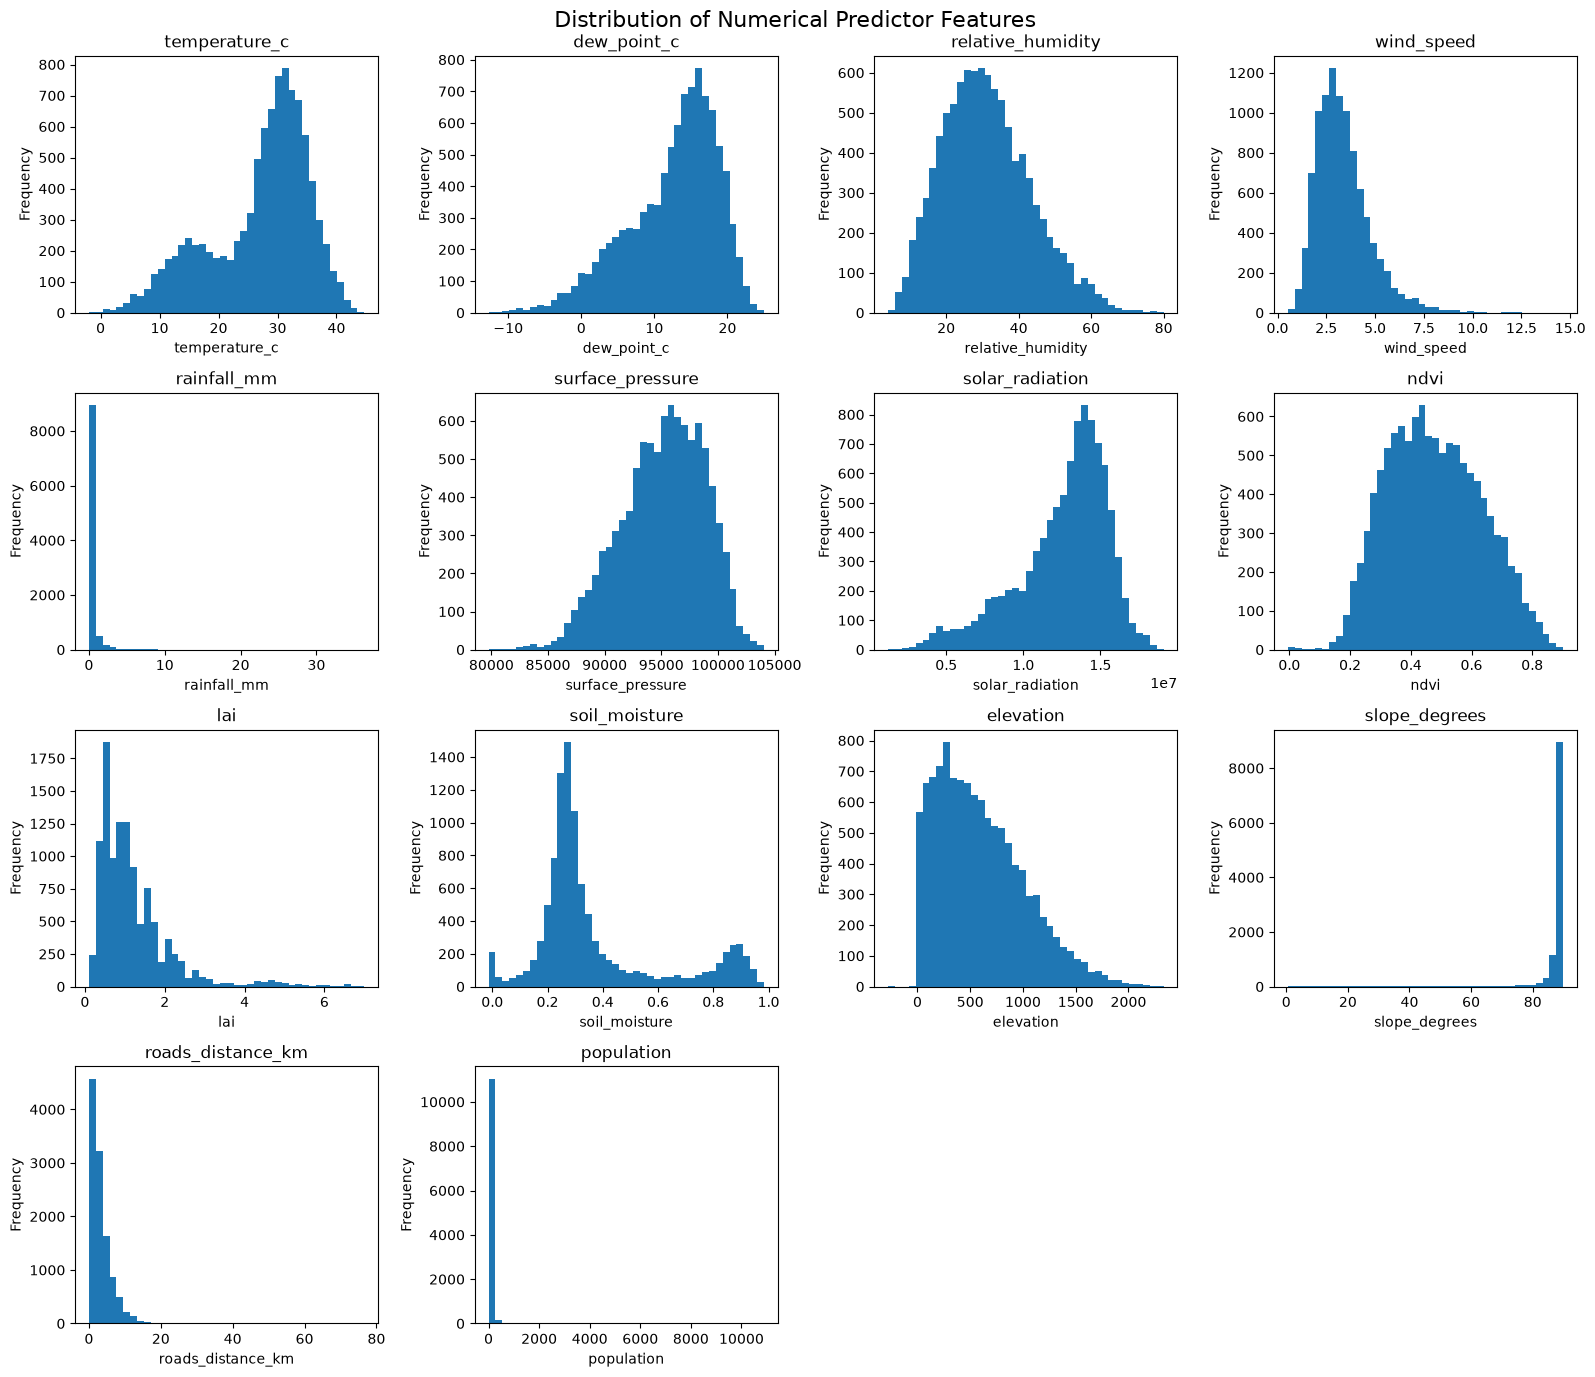

In [32]:
features_to_plot = [
    "temperature_c",
    "dew_point_c",
    "relative_humidity",
    "wind_speed",
    "rainfall_mm",
    "surface_pressure",
    "solar_radiation",
    "ndvi",
    "lai",
    "soil_moisture",
    "elevation",
    "slope_degrees",
    "roads_distance_km",
    "population"
]

fig, axes = plt.subplots(4, 4, figsize=(16, 14))

axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    axes[i].hist(
        df[feature].dropna(),
        bins=40
    )
    
    axes[i].set_title(feature)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Frequency")

# Hide unused subplot
for j in range(len(features_to_plot), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    "Distribution of Numerical Predictor Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

##  Investigation of Slope Distribution

The slope feature shows an unusual concentration of observations close to 90 degrees.

Before preprocessing, the distribution must be investigated to determine whether:

1. the values represent a valid terrain slope measurement,
2. the source dataset uses an unusual slope convention,
3. the values require conversion,
4. or the feature contains a data-quality issue.

The feature will not be removed or transformed until its meaning and value distribution are confirmed.

In [33]:
print("Slope statistics:")
print(df["slope_degrees"].describe())

print("\nSelected slope percentiles:")
print(
    df["slope_degrees"].quantile(
        [0, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1.0]
    )
)

print("\nNumber of observations by slope range:")

slope_bins = [-np.inf, 1, 5, 10, 20, 30, 45, 60, 75, 80, 85, 88, 89, 90]

slope_counts = pd.cut(
    df["slope_degrees"],
    bins=slope_bins,
    include_lowest=True
).value_counts().sort_index()

display(slope_counts.to_frame("records"))

Slope statistics:
count    11305.000000
mean        86.155834
std         11.587054
min          0.492195
25%         88.019097
50%         89.052826
75%         89.464400
max         89.878507
Name: slope_degrees, dtype: float64

Selected slope percentiles:
0.00     0.492195
0.01    14.025520
0.05    75.804527
0.10    85.153043
0.25    88.019097
0.50    89.052826
0.75    89.464400
0.90    89.651634
0.95    89.716088
0.99    89.797943
1.00    89.878507
Name: slope_degrees, dtype: float64

Number of observations by slope range:


,records
slope_degrees,
"(-inf, 1.0]",1
"(1.0, 5.0]",31
"(5.0, 10.0]",48
"(10.0, 20.0]",67
"(20.0, 30.0]",50
"(30.0, 45.0]",79
"(45.0, 60.0]",105
"(60.0, 75.0]",170
"(75.0, 80.0]",135


In [39]:
from pathlib import Path
import xarray as xr
import numpy as np

# Project root
PROJECT_ROOT = Path.cwd().parents[1]

# Original Mesogeos NetCDF dataset
MESOGEOS_ROOT = PROJECT_ROOT / "dataset" / "mesogeos_dataset"

print("Mesogeos dataset path:")
print(MESOGEOS_ROOT)

# Find the first NetCDF file
sample_file = next(MESOGEOS_ROOT.rglob("*.nc"))

print("\nSample NetCDF file:")
print(sample_file)

# Open it
ds_sample = xr.open_dataset(sample_file)

# Original slope
slope_original = ds_sample["slope"]

print("\nOriginal slope dimensions:")
print(slope_original.dims)

print("\nOriginal slope statistics:")
print("Minimum:", slope_original.min().values)
print("Maximum:", slope_original.max().values)
print("Mean:", slope_original.mean().values)

print("\nOriginal slope percentiles:")

percentiles = np.nanpercentile(
    slope_original.values,
    [0, 1, 5, 25, 50, 75, 95, 99, 100]
)

print(percentiles)

ds_sample.close()

Mesogeos dataset path:
c:\Projects\ML Based Forest-Fire Prediction Project\dataset\mesogeos_dataset

Sample NetCDF file:
c:\Projects\ML Based Forest-Fire Prediction Project\dataset\mesogeos_dataset\2006\sample_0.nc

Original slope dimensions:
('y', 'x')

Original slope statistics:
Minimum: 0.3444779
Maximum: 1.5576952
Mean: 1.4373785

Original slope percentiles:
[0.34447789 0.98009053 1.23684078 1.40806204 1.4681679  1.50565892
 1.53640163 1.54880173 1.55769515]


## Slope Feature Interpretation

The terrain slope variable was originally stored in radians in the Mesogeos NetCDF files.

The original NetCDF data was inspected to verify that the unusual distribution observed in the CSV was not caused by an incorrect unit conversion.

The original slope values ranged from approximately 0.34 to 1.56 radians, corresponding to approximately 19.7° to 89.3°. The distribution was already strongly concentrated toward high slope values in the original source data.

Therefore, the radians-to-degrees conversion used during dataset creation is considered valid.

The high concentration of slope values near 90° is treated as a characteristic of the source dataset rather than an error introduced during preprocessing.

The feature will therefore be retained for modelling. Its actual predictive usefulness will be evaluated later through feature importance and model validation.

In [ ]:
# STEP 29 — LAND-COVER FEATURE INVESTIGATION

land_cover_features = [
    "lc_agriculture",
    "lc_forest",
    "lc_grassland",
    "lc_settlement",
    "lc_shrubland",
    "lc_sparse_vegetation",
    "lc_water_bodies",
    "lc_wetland"
]

land_cover_summary = pd.DataFrame({
    "mean": df[land_cover_features].mean(),
    "median": df[land_cover_features].median(),
    "min": df[land_cover_features].min(),
    "max": df[land_cover_features].max(),
    "zero_count": (df[land_cover_features] == 0).sum(),
    "zero_percentage": (df[land_cover_features] == 0).mean() * 100
})

display(land_cover_summary)

,mean,median,min,max,zero_count,zero_percentage
lc_agriculture,0.369136,0.241706,0.0,1.000000,2535,22.423706
lc_forest,0.427536,0.343561,0.0,1.000000,3141,27.784166
lc_grassland,0.098834,0.000000,0.0,1.000000,7836,69.314463
lc_settlement,0.006275,0.000000,0.0,0.983669,10709,94.727996
lc_shrubland,0.062152,0.000000,0.0,1.000000,9093,80.433437
lc_sparse_vegetation,0.015222,0.000000,0.0,1.000000,10135,89.650597
lc_water_bodies,0.006165,0.000000,0.0,1.000000,10964,96.983636
lc_wetland,0.014681,0.000000,0.0,1.000000,10996,97.266696


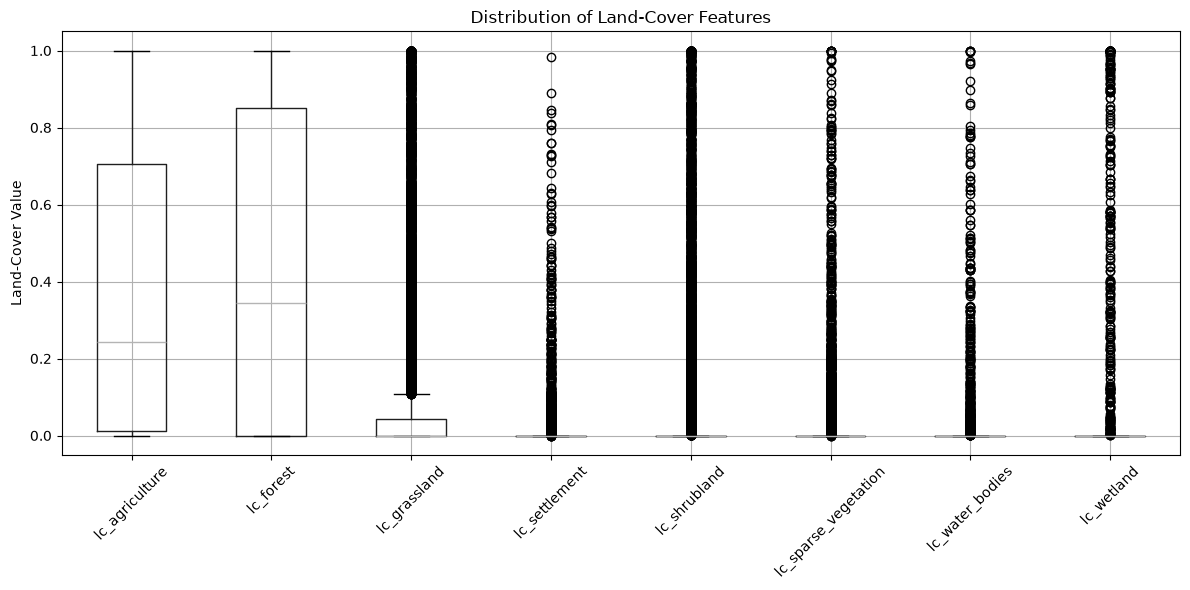

In [ ]:
# LAND-COVER DISTRIBUTIONS

plt.figure(figsize=(12, 6))

df[land_cover_features].boxplot()

plt.title("Distribution of Land-Cover Features")
plt.ylabel("Land-Cover Value")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# STEP 30 — LAND-COVER COMPOSITION CHECK

land_cover_features = [
    "lc_agriculture",
    "lc_forest",
    "lc_grassland",
    "lc_settlement",
    "lc_shrubland",
    "lc_sparse_vegetation",
    "lc_water_bodies",
    "lc_wetland"
]

df["land_cover_total"] = df[land_cover_features].sum(axis=1)

print("Land-cover total statistics:")
print(df["land_cover_total"].describe())

print("\nLand-cover total percentiles:")
print(
    df["land_cover_total"].quantile(
        [0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1.0]
    )
)

Land-cover total statistics:
count    1.130500e+04
mean     1.000000e+00
std      1.871307e-08
min      9.999999e-01
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: land_cover_total, dtype: float64

Land-cover total percentiles:
0.00    1.0
0.01    1.0
0.05    1.0
0.25    1.0
0.50    1.0
0.75    1.0
0.95    1.0
0.99    1.0
1.00    1.0
Name: land_cover_total, dtype: float64


In [43]:
# Check how close land-cover totals are to 1

difference_from_one = (df["land_cover_total"] - 1).abs()

print("Records approximately summing to 1:")
print((difference_from_one < 0.01).sum())

print("\nPercentage approximately summing to 1:")
print((difference_from_one < 0.01).mean() * 100)

print("\nRecords with land-cover total > 1:")
print((df["land_cover_total"] > 1.01).sum())

print("\nRecords with land-cover total < 0.99:")
print((df["land_cover_total"] < 0.99).sum())

Records approximately summing to 1:
11305

Percentage approximately summing to 1:
100.0

Records with land-cover total > 1:
0

Records with land-cover total < 0.99:
0


In [44]:
df["land_cover_total"]

0        1.0
1        1.0
2        1.0
3        1.0
4        1.0
        ... 
11300    1.0
11301    1.0
11302    1.0
11303    1.0
11304    1.0
Name: land_cover_total, Length: 11305, dtype: float64

In [45]:
# Remove temporary investigation feature
df.drop(columns=["land_cover_total"], inplace=True)

print("Temporary land-cover column removed.")
print("Dataset shape:", df.shape)

Temporary land-cover column removed.
Dataset shape: (11305, 33)


## Interpretation — Land-Cover Composition

The eight land-cover variables were investigated to understand their distributions and whether they represent meaningful environmental characteristics.

The results show that the land-cover variables have different levels of representation across the wildfire locations. Forest and agriculture are the dominant land-cover classes, with mean proportions of approximately 0.43 and 0.37 respectively. This indicates that these two land-cover types account for a substantial proportion of the environments represented in the dataset.

Other land-cover classes occur less frequently. Grassland has a mean proportion of approximately 0.10, while shrubland has a mean proportion of approximately 0.06. Settlement, sparse vegetation, water bodies, and wetland have substantially lower mean proportions and contain a high percentage of zero values.

The presence of many zero values in these features does not necessarily indicate missing or invalid data. Instead, it is consistent with the interpretation that a particular land-cover class is absent from the area surrounding a wildfire location.

A composition check was also performed by summing all eight land-cover variables for each record. The results showed that all 11,305 records have a land-cover total approximately equal to 1. This confirms that the variables represent proportions of the overall land-cover composition.

Because the land-cover variables form a compositional dataset, their values are mathematically related. Increasing the proportion of one land-cover type necessarily reduces the relative contribution of one or more other types. Therefore, an additional `land_cover_total` feature would provide no useful information and was not retained for modelling.

### Decision

- All eight original land-cover features will be retained.
- The temporary `land_cover_total` investigation feature will be removed.
- No land-cover feature will be removed solely because of a high number of zero values.
- Their predictive usefulness will be evaluated later using feature importance and model validation.

## Population and Road Distance Investigation

The `population` and `roads_distance_km` features represent human and accessibility-related characteristics around wildfire locations.

These variables are expected to be highly skewed because:

- Population is usually concentrated around a relatively small number of populated areas.
- Many wildfire locations may occur in areas with very low population.
- Most wildfire locations may be relatively close to roads, while a smaller number may be located much farther away.

The distributions of these variables will therefore be investigated to determine:

1. Their overall statistical distribution.
2. The proportion of zero values.
3. The presence of extreme observations.
4. Whether the extreme values appear to be plausible.
5. Whether a transformation such as `log1p()` may be useful during later feature engineering.

Extreme values will not be removed at this stage because they may represent genuine geographic conditions rather than errors.

In [46]:
features = ["population", "roads_distance_km"]

summary = pd.DataFrame({
    "mean": df[features].mean(),
    "median": df[features].median(),
    "std": df[features].std(),
    "min": df[features].min(),
    "max": df[features].max(),
    "zero_count": (df[features] == 0).sum(),
    "zero_percentage": (df[features] == 0).mean() * 100
})

display(summary)

,mean,median,std,min,max,zero_count,zero_percentage
population,34.989059,5.373124,192.941367,0.0,10888.974609,738,6.528085
roads_distance_km,3.323850,2.445000,3.294294,0.0,76.629997,450,3.980540


In [47]:
percentiles = [0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1.00]

population_percentiles = df["population"].quantile(percentiles)
roads_percentiles = df["roads_distance_km"].quantile(percentiles)

print("Population percentiles:")
display(population_percentiles.to_frame("population"))

print("\nRoad distance percentiles:")
display(roads_percentiles.to_frame("roads_distance_km"))

Population percentiles:


,population
0.00,0.000000
0.01,0.000000
0.05,0.000000
0.25,1.352838
0.50,5.373124
0.75,18.404131
0.90,58.951706
0.95,119.640686
0.99,507.483295
1.00,10888.974609



Road distance percentiles:


,roads_distance_km
0.00,0.000000
0.01,0.000000
0.05,0.093000
0.25,1.166000
0.50,2.445000
0.75,4.477000
0.90,7.325600
0.95,9.190200
0.99,14.455880
1.00,76.629997


## Interpretation — Population and Road Distance

### Population

The `population` feature is strongly right-skewed.

- The median population value is approximately **5.37**.
- 75% of observations have a population value below approximately **18.40**.
- 90% of observations are below approximately **58.95**.
- 95% are below approximately **119.64**.
- However, the maximum value is approximately **10,888.97**.

This large difference between the median and maximum indicates the presence of a small number of locations with substantially higher population values.

Approximately **6.53%** of records have a population value of zero. This is reasonable because many wildfire locations occur in rural or sparsely populated areas.

The extreme population values should not automatically be treated as errors. They may represent wildfire observations located near populated regions. Therefore, these observations will be retained.

Because of the strong right-skewness, a logarithmic transformation such as `log1p(population)` may be considered during feature engineering.

---

### Road Distance

The `roads_distance_km` feature is also right-skewed.

- The median distance from roads is approximately **2.45 km**.
- 75% of observations are within approximately **4.48 km** of a road.
- 90% are within approximately **7.33 km**.
- 95% are within approximately **9.19 km**.
- 99% are within approximately **14.46 km**.
- The maximum value is approximately **76.63 km**.

Approximately **3.98%** of records have a road distance of zero. These observations may represent locations directly on or extremely close to roads.

The relatively large maximum compared with the median indicates a small number of geographically isolated wildfire locations.

As with population, these extreme values will not be removed automatically because they may represent legitimate geographic conditions.

A `log1p()` transformation may also be useful for `roads_distance_km` because of its right-skewed distribution.

### Overall Finding

Both `population` and `roads_distance_km` contain highly skewed distributions with relatively small numbers of extreme observations.

For preprocessing:

- **Do not remove the extreme values at this stage.**
- Retain the original variables.
- Consider `log1p()` transformations during feature engineering.
- Missing population values will need to be handled during preprocessing.
- These features may provide useful geographic/contextual information for wildfire burned-area prediction.

## Population and Road Distance Distributions

The numerical analysis indicated strong right-skewness in both `population` and `roads_distance_km`.

Histograms will be used to visually examine their distributions and identify whether a small number of extreme observations dominate the scale.

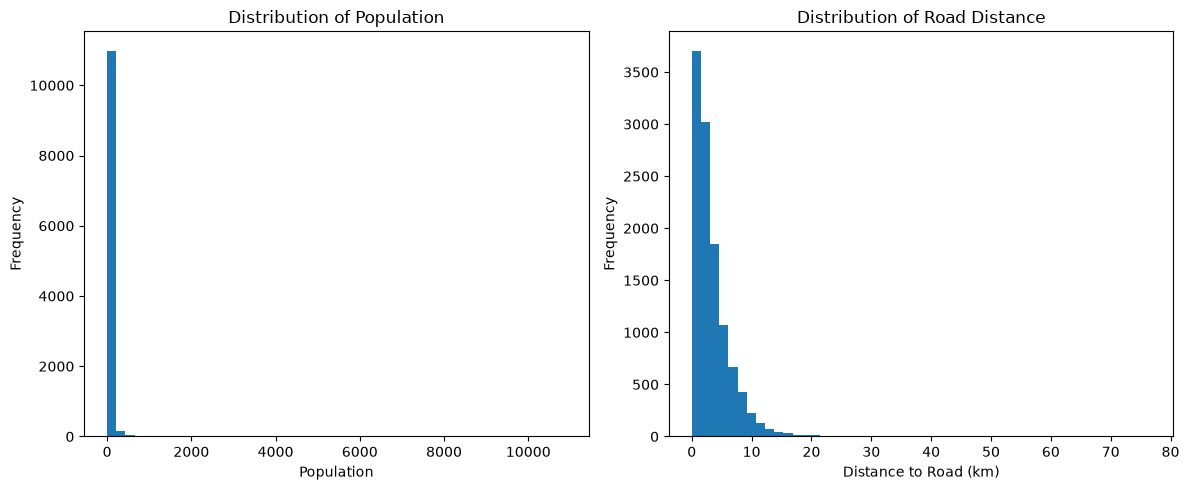

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Population
axes[0].hist(df["population"].dropna(), bins=50)
axes[0].set_title("Distribution of Population")
axes[0].set_xlabel("Population")
axes[0].set_ylabel("Frequency")

# Road distance
axes[1].hist(df["roads_distance_km"].dropna(), bins=50)
axes[1].set_title("Distribution of Road Distance")
axes[1].set_xlabel("Distance to Road (km)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## Interpretation — Population and Road Distance Distributions

### Population Distribution

The population distribution is **strongly right-skewed**.

The histogram shows that the vast majority of wildfire records occur in locations with relatively low population values, while a small number of observations have substantially higher population values.

This agrees with the percentile analysis:

- Median: approximately **5.37**
- 75th percentile: approximately **18.40**
- 90th percentile: approximately **58.95**
- 95th percentile: approximately **119.64**
- Maximum: approximately **10,888.97**

The extreme values are not automatically considered errors because they may represent wildfire locations close to populated areas.

The strong skewness suggests that a logarithmic transformation such as `log1p(population)` may be useful during feature engineering.

---

### Road Distance Distribution

The `roads_distance_km` feature is also **strongly right-skewed**.

Most wildfire records are located relatively close to roads. The frequency decreases rapidly as the distance from roads increases.

The percentile analysis showed:

- Median: approximately **2.45 km**
- 75th percentile: approximately **4.48 km**
- 90th percentile: approximately **7.33 km**
- 95th percentile: approximately **9.19 km**
- 99th percentile: approximately **14.46 km**
- Maximum: approximately **76.63 km**

The long right tail represents a relatively small number of wildfire locations that are much farther from roads.

These observations will be retained because they may represent legitimate geographically isolated wildfire events.

A `log1p()` transformation may also be considered for this feature during feature engineering.

---

### Overall Finding

Both features show substantial right-skewness.

Therefore:

1. Extreme values will **not be removed automatically**.
2. The original features will be retained.
3. `log1p()` transformations may be evaluated during feature engineering.
4. Missing population values will be handled during preprocessing.
5. Both features will remain candidates for the machine-learning model because they may provide useful geographical information.

The exploratory analysis confirms that **population and road distance require appropriate preprocessing but do not currently show evidence that they should be discarded.**

## Temporal Feature Investigation

The dataset contains three temporal variables:

- `year`
- `month`
- `day_of_year`

Temporal patterns are important for wildfire prediction because fire activity can vary substantially between seasons and years.

This section investigates:

1. Number of wildfire records by year
2. Number of wildfire records by month
3. Total burned area by year
4. Total burned area by month
5. Median burned area by month
6. Seasonal wildfire patterns

The purpose is to determine whether temporal variables contain useful predictive information and whether they should be retained during feature engineering.

###  Wildfire Records by Year

The number of wildfire records is examined for each year to determine whether the dataset contains substantial variation in wildfire observations over time.

In [49]:
# Wildfire records by year

year_counts = df.groupby("year").size()

display(year_counts.to_frame("wildfire_records"))

,wildfire_records
year,
2006,214
2007,603
2008,296
2009,456
2010,420
2011,781
2012,1046
2013,424
2014,320


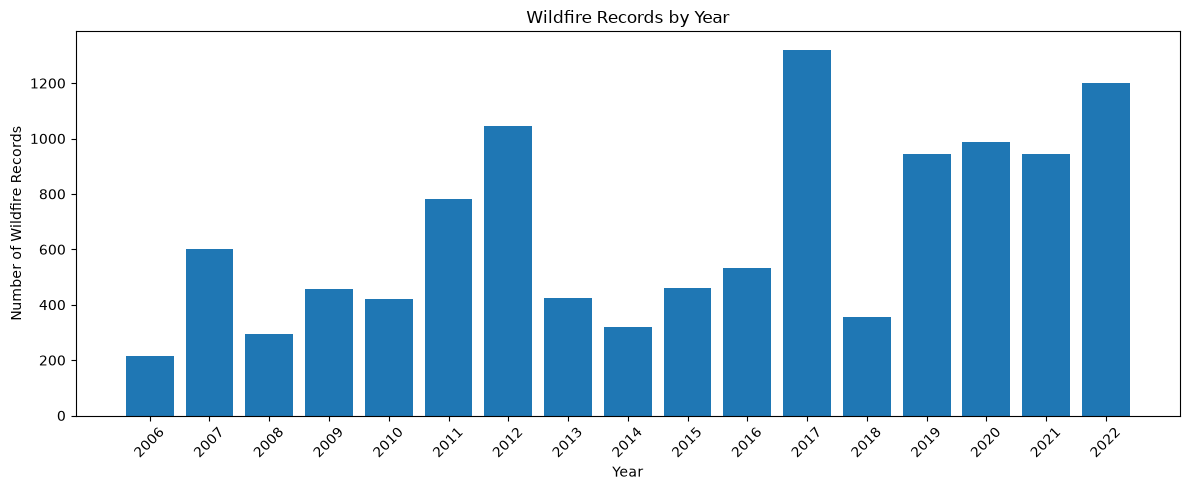

In [50]:
plt.figure(figsize=(12, 5))

plt.bar(year_counts.index, year_counts.values)

plt.title("Wildfire Records by Year")
plt.xlabel("Year")
plt.ylabel("Number of Wildfire Records")

plt.xticks(year_counts.index, rotation=45)

plt.tight_layout()
plt.show()

### Interpretation — Wildfire Records by Year

The number of wildfire records varies considerably across the 2006–2022 period.

The dataset contains the highest number of wildfire records in:

- **2017:** 1,321 records
- **2022:** 1,200 records
- **2012:** 1,046 records
- **2020:** 987 records
- **2021:** 945 records
- **2019:** 943 records

The lowest number of records occurs in:

- **2006:** 214 records
- **2008:** 296 records
- **2014:** 320 records
- **2018:** 357 records

The number of observations increases substantially in several later years, particularly from 2019 onwards.

However, the number of records in a particular year does **not necessarily indicate that wildfire activity was actually higher in that year**. The variation may also reflect differences in data availability, sampling, spatial coverage, or the number of source records available for each year.

Therefore, the year distribution should be considered when interpreting temporal patterns.

### Modelling Implication

The `year` feature should be retained for further investigation because wildfire characteristics may change over time.

However, it should **not be interpreted directly as a measure of wildfire severity**. The target variable, `burned_area_ha`, must be examined separately by year.

The next analysis will compare burned-area statistics across years to determine whether the variation in observations is accompanied by meaningful differences in wildfire size.

### Burned Area by Year

The number of records alone does not indicate whether wildfire severity changed between years.

Therefore, the burned-area target will be aggregated by year using:

- Mean burned area
- Median burned area
- Total burned area
- Maximum burned area

The median is particularly important because the burned-area target is highly right-skewed and can be strongly affected by extreme wildfire events.

In [51]:
# Burned area statistics by year

year_burned_area = (
    df.groupby("year")["burned_area_ha"]
    .agg(
        fires="count",
        mean="mean",
        median="median",
        total="sum",
        maximum="max"
    )
)

display(year_burned_area)

,fires,mean,median,total,maximum
year,,,,,
2006,214,428.070093,162.0,91607.0,6837.0
2007,603,893.716418,225.0,538911.0,45809.0
2008,296,426.141892,158.5,126138.0,16407.0
2009,456,548.526316,161.0,250128.0,20521.0
2010,420,382.071429,139.0,160470.0,10804.0
2011,781,319.870679,131.0,249819.0,6245.0
2012,1046,614.507648,192.0,642775.0,32424.0
2013,424,454.917453,147.5,192885.0,15015.0
2014,320,401.590625,165.0,128509.0,6327.0


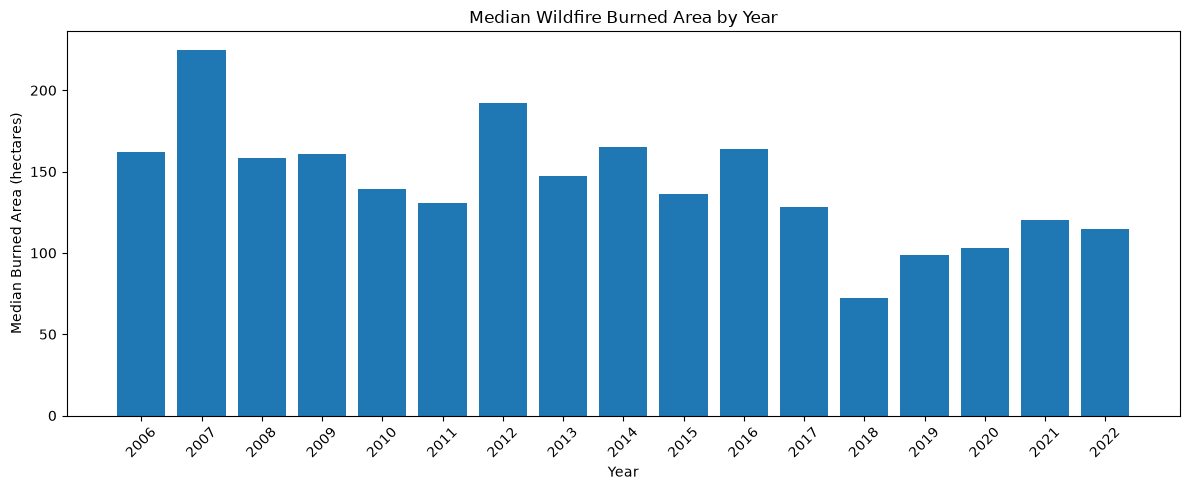

In [52]:
plt.figure(figsize=(12, 5))

plt.bar(
    year_burned_area.index,
    year_burned_area["median"]
)

plt.title("Median Wildfire Burned Area by Year")
plt.xlabel("Year")
plt.ylabel("Median Burned Area (hectares)")

plt.xticks(year_burned_area.index, rotation=45)

plt.tight_layout()
plt.show()

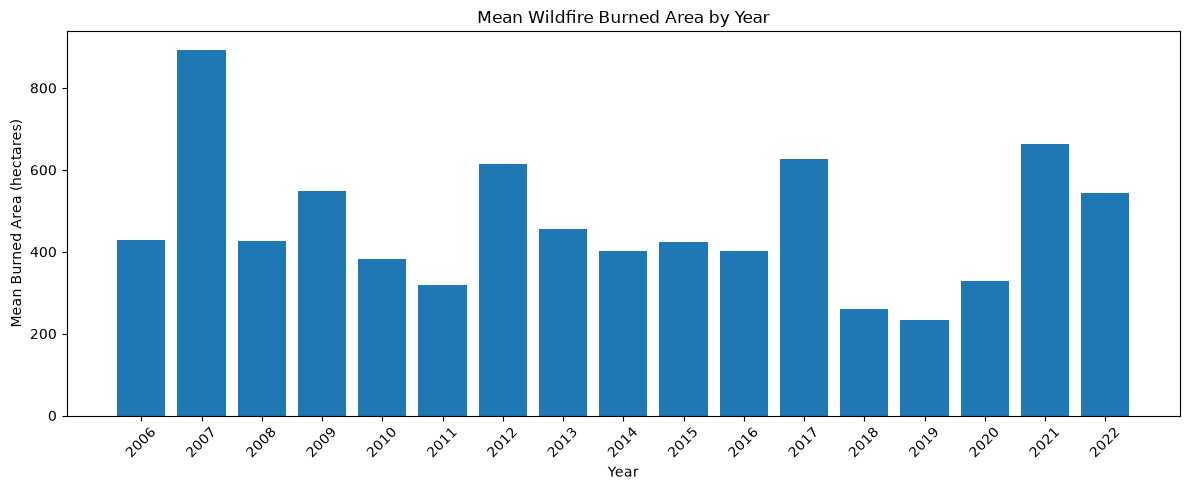

In [53]:
plt.figure(figsize=(12, 5))

plt.bar(
    year_burned_area.index,
    year_burned_area["mean"]
)

plt.title("Mean Wildfire Burned Area by Year")
plt.xlabel("Year")
plt.ylabel("Mean Burned Area (hectares)")

plt.xticks(year_burned_area.index, rotation=45)

plt.tight_layout()
plt.show()

### Interpretation — Burned Area by Year

The yearly burned-area statistics show substantial variation in wildfire severity between 2006 and 2022.

#### Median Burned Area

The median burned area provides a more robust representation of the typical wildfire because the target variable contains extreme values.

The highest yearly median burned areas were observed in:

- **2007:** 225 ha
- **2012:** 192 ha
- **2014:** 165 ha
- **2016:** 164 ha
- **2009:** 161 ha

The lowest yearly median values were observed in:

- **2018:** 72 ha
- **2019:** 99 ha
- **2020:** 103 ha
- **2022:** 115 ha

This indicates that the typical wildfire size varied considerably across years.

#### Mean Burned Area

The mean burned area is much more sensitive to extreme wildfire events.

The highest mean burned areas occurred in:

- **2007:** approximately 893.7 ha
- **2021:** approximately 662.5 ha
- **2017:** approximately 625.8 ha
- **2012:** approximately 614.5 ha
- **2022:** approximately 544.2 ha

The lowest mean values occurred in:

- **2019:** approximately 232.3 ha
- **2018:** approximately 260.7 ha
- **2011:** approximately 319.9 ha

The difference between mean and median is particularly large in several years. For example, in 2007 the median burned area was **225 ha**, while the mean was approximately **893.7 ha**.

This difference indicates that a relatively small number of very large wildfire events substantially increase the yearly mean.

#### Extreme Events

The dataset contains several exceptionally large wildfire events. The largest observed event occurred in **2017**, with a burned area of **107,602 ha**.

These extreme events have a strong influence on the mean burned-area statistics.

Therefore, the median is more appropriate for describing the typical wildfire, while the mean and maximum values are useful for understanding the influence of extreme events.

#### Important Consideration

The number of records varies substantially between years. For example, 2006 contains only **214 records**, while 2017 contains **1,321 records**.

Consequently, differences between years should not automatically be interpreted as changes in real-world wildfire activity. They may also reflect differences in data coverage, sampling, or observation frequency.

### Modelling Implication

The temporal variables should be retained for further analysis because the target shows meaningful variation across years.

However, the analysis suggests that `year` may capture both temporal effects and differences in data collection.

The extreme skewness of `burned_area_ha` also supports evaluating a log-transformed target during model development.

### Wildfire Records by Month

Wildfire occurrence is expected to have a strong seasonal component.

The number of wildfire records is therefore examined by month to determine whether observations are concentrated during particular periods of the year.

In [56]:
# Wildfire records by month

month_counts = df.groupby("month").size()

display(month_counts.to_frame("wildfire_records"))

,wildfire_records
month,
1,157
2,375
3,1025
4,411
5,198
6,707
7,2761
8,3587
9,1313


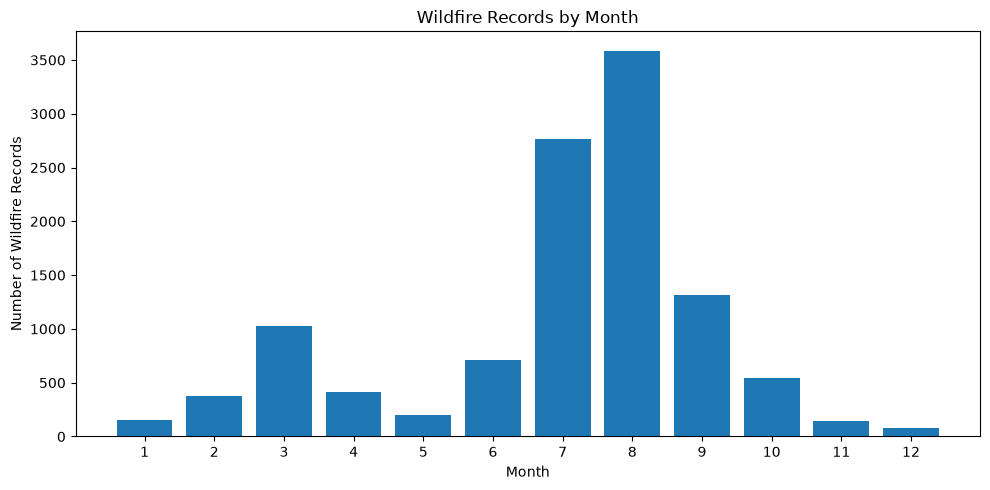

In [57]:
plt.figure(figsize=(10, 5))

plt.bar(
    month_counts.index,
    month_counts.values
)

plt.title("Wildfire Records by Month")
plt.xlabel("Month")
plt.ylabel("Number of Wildfire Records")

plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

### Burned Area by Month

The number of wildfire records does not necessarily correspond to wildfire severity.

Therefore, burned-area statistics are aggregated by month using:

- Mean burned area
- Median burned area
- Total burned area
- Maximum burned area

The median will be emphasized because the burned-area target is highly right-skewed.

In [58]:
# Burned area statistics by month

month_burned_area = (
    df.groupby("month")["burned_area_ha"]
    .agg(
        fires="count",
        mean="mean",
        median="median",
        total="sum",
        maximum="max"
    )
)

display(month_burned_area)

,fires,mean,median,total,maximum
month,,,,,
1,157,300.299363,99.0,47147.0,6060.0
2,375,244.760000,89.0,91785.0,5842.0
3,1025,243.349268,105.0,249433.0,6700.0
4,411,280.002433,96.0,115081.0,14160.0
5,198,251.666667,82.5,49830.0,7005.0
6,707,595.304102,140.0,420880.0,46769.0
7,2761,619.556682,182.0,1710596.0,54769.0
8,3587,573.638417,145.0,2057641.0,51245.0
9,1313,283.332064,113.0,372015.0,15536.0


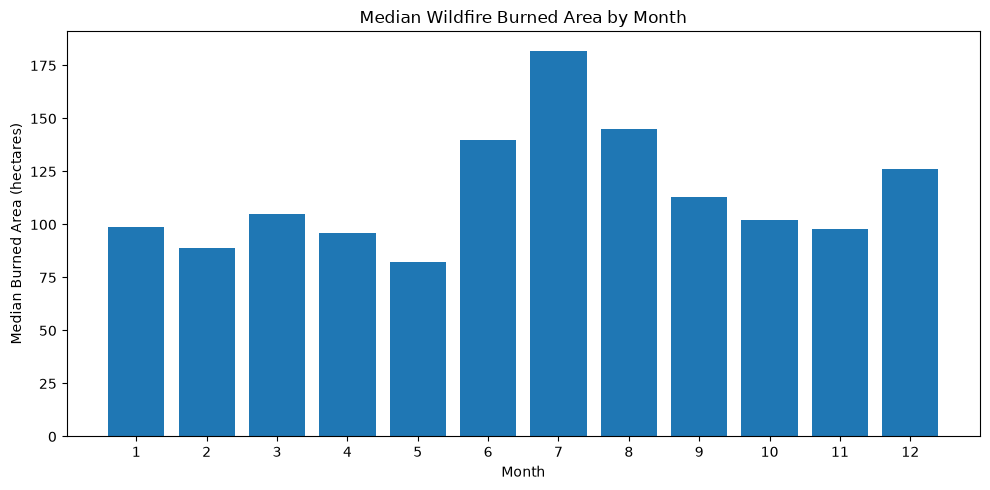

In [59]:
plt.figure(figsize=(10, 5))

plt.bar(
    month_burned_area.index,
    month_burned_area["median"]
)

plt.title("Median Wildfire Burned Area by Month")
plt.xlabel("Month")
plt.ylabel("Median Burned Area (hectares)")

plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

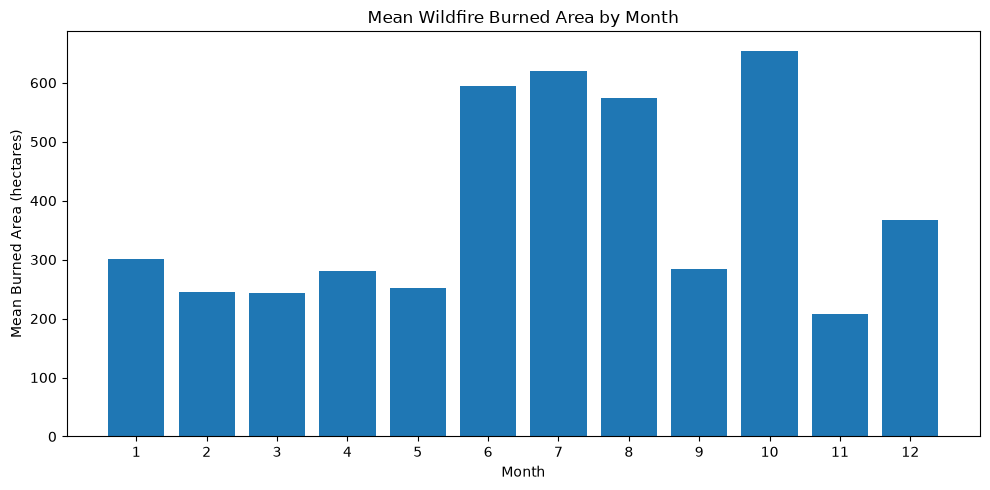

In [60]:
plt.figure(figsize=(10, 5))

plt.bar(
    month_burned_area.index,
    month_burned_area["mean"]
)

plt.title("Mean Wildfire Burned Area by Month")
plt.xlabel("Month")
plt.ylabel("Mean Burned Area (hectares)")

plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

## Seasonal Pattern Using Day of Year

The `day_of_year` variable provides a continuous representation of the position of each observation within the year.

Unlike the `month` variable, `day_of_year` provides finer temporal resolution and can help identify seasonal patterns within individual months.

The relationship between day of year and burned area will be examined using the log-transformed target because the raw burned-area distribution is strongly right-skewed.

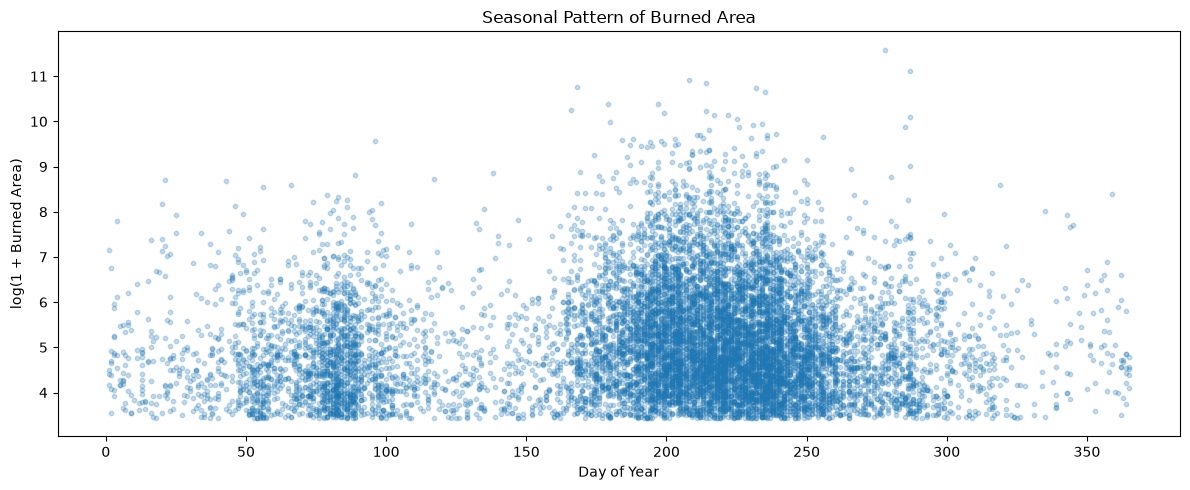

In [61]:
# Seasonal relationship between day of year and burned area

plt.figure(figsize=(12, 5))

plt.scatter(
    df["day_of_year"],
    np.log1p(df["burned_area_ha"]),
    alpha=0.25,
    s=10
)

plt.title("Seasonal Pattern of Burned Area")
plt.xlabel("Day of Year")
plt.ylabel("log(1 + Burned Area)")

plt.tight_layout()
plt.show()

## Target Structure & Extreme Wildfire Events

The target variable, `burned_area_ha`, represents the burned forest area in hectares.

Before preprocessing and model development, it is important to examine the structure of the target variable in greater detail. In particular, we investigate:

- the presence of zero or near-zero burned-area observations,
- the distribution of burned-area ranges,
- the frequency of large wildfire events,
- the proportion of observations represented by extreme values.

This analysis is important because wildfire burned-area data can contain substantial variability and extreme events. Such observations may strongly influence regression models and therefore need to be understood before selecting preprocessing and modelling strategies.

In [62]:
target = df["burned_area_ha"]

zero_count = (target == 0).sum()
nonzero_count = (target > 0).sum()

print("Zero burned-area records:", zero_count)
print("Non-zero burned-area records:", nonzero_count)

print("\nMinimum burned area:", target.min())
print("Maximum burned area:", target.max())

Zero burned-area records: 0
Non-zero burned-area records: 11305

Minimum burned area: 30.0
Maximum burned area: 107602.0


In [63]:
bins = [
    0,
    100,
    500,
    1000,
    5000,
    10000,
    50000,
    np.inf
]

labels = [
    "30–100 ha",
    "101–500 ha",
    "501–1,000 ha",
    "1,001–5,000 ha",
    "5,001–10,000 ha",
    "10,001–50,000 ha",
    ">50,000 ha"
]

target_ranges = pd.cut(
    target,
    bins=bins,
    labels=labels,
    include_lowest=True
)

range_counts = target_ranges.value_counts().sort_index()

range_summary = pd.DataFrame({
    "records": range_counts,
    "percentage": (range_counts / len(df) * 100).round(2)
})

display(range_summary)

,records,percentage
burned_area_ha,,
30–100 ha,4569,40.42
101–500 ha,4748,42.00
"501–1,000 ha",1013,8.96
"1,001–5,000 ha",831,7.35
"5,001–10,000 ha",86,0.76
"10,001–50,000 ha",54,0.48
">50,000 ha",4,0.04


### Interpretation — Burned-Area Severity Distribution

The burned-area range analysis shows that the target variable is strongly concentrated toward smaller wildfire events. Approximately 82.42% of observations have burned areas between 30 and 500 hectares.

Only 8.63% of observations exceed 1,000 hectares, while observations above 10,000 hectares are extremely rare. Four observations exceed 50,000 hectares, representing only 0.04% of the dataset.

This demonstrates a highly imbalanced regression target distribution, where the model has substantially more examples of moderate wildfire events than extreme wildfire events.

The extreme observations should not be automatically removed because they may represent genuine high-severity wildfire events. However, their strong influence on regression models should be considered during preprocessing and model development.

The substantial right-skewness and extreme range of the target support evaluating a logarithmic transformation such as `log1p(burned_area_ha)` during model training. The original target values will be retained for interpretation and final prediction reporting.

In [64]:
# ============================================================
# FINAL EXTREME WILDFIRE EVENT ANALYSIS
# ============================================================

p90 = target.quantile(0.90)
p95 = target.quantile(0.95)
p99 = target.quantile(0.99)
p999 = target.quantile(0.999)

print("Target percentile thresholds:")
print(f"90th percentile : {p90:.2f} ha")
print(f"95th percentile : {p95:.2f} ha")
print(f"99th percentile : {p99:.2f} ha")
print(f"99.9th percentile: {p999:.2f} ha")

print("\nNumber of observations above each threshold:")

print("Above 90th percentile :", (target > p90).sum())
print("Above 95th percentile :", (target > p95).sum())
print("Above 99th percentile :", (target > p99).sum())
print("Above 99.9th percentile:", (target > p999).sum())

print("\nLargest wildfire events:")

extreme_events = df[
    df["burned_area_ha"] >= p99
].copy()

display(
    extreme_events[
        [
            "date",
            "latitude",
            "longitude",
            "burned_area_ha",
            "year",
            "month"
        ]
    ]
    .sort_values("burned_area_ha", ascending=False)
    .head(20)
)

Target percentile thresholds:
90th percentile : 868.60 ha
95th percentile : 1665.00 ha
99th percentile : 5900.20 ha
99.9th percentile: 26096.35 ha

Number of observations above each threshold:
Above 90th percentile : 1131
Above 95th percentile : 564
Above 99th percentile : 114
Above 99.9th percentile: 12

Largest wildfire events:


,date,latitude,longitude,burned_area_ha,year,month
6183,2017-10-05,40.187787,-7.889716,107602.0,2017,10
6419,2017-10-14,40.167649,-8.211923,67521.0,2017,10
9168,2021-07-27,36.875095,31.379274,54769.0,2021,7
9178,2021-08-02,38.828476,23.334165,51245.0,2021,8
6007,2017-06-17,40.026683,-8.302544,46769.0,2017,6
725,2007-08-20,37.428889,22.045337,45809.0,2007,8
298,2007-08-23,37.438958,22.266854,42350.0,2007,8
10645,2022-07-16,41.738409,-6.047094,32528.0,2022,7
3151,2012-06-27,39.281580,-0.841436,32424.0,2012,6
10718,2022-06-15,41.899512,-6.228336,28046.0,2022,6


# EDA Final Conclusion

The exploratory data analysis provides a comprehensive understanding of the MESOGEOS wildfire dataset and identifies several characteristics that are important for subsequent preprocessing and machine learning.

## Dataset characteristics

The dataset contains **11,305 wildfire records and 32 variables** covering the period from **2006 to 2022**. The data contain meteorological, geographic, topographic, land-cover, temporal, and wildfire-related variables.

The target variable is `burned_area_ha`, representing the burned forest area in hectares.

## Data quality

The dataset contains missing values in several meteorological and environmental variables. The missing values are not uniformly distributed across the dataset and are particularly concentrated during certain months and years.

There are also two duplicate records, which will need to be handled during preprocessing.

The investigation of the original MESOGEOS NetCDF files confirmed that the unusual distribution observed in the `slope_degrees` variable is related to the source data rather than being caused by an accidental transformation during CSV creation.

## Target-variable characteristics

The target variable contains no zero observations. All 11,305 records have a positive burned area, with values ranging from **30 hectares to 107,602 hectares**.

The target distribution is strongly right-skewed. Approximately **82.42%** of observations fall between 30 and 500 hectares, while only a small proportion represent very large wildfire events.

The 99th percentile is approximately **5,900 hectares**, meaning that only about 1% of observations exceed this value. The 99.9th percentile is approximately **26,096 hectares**, with only 12 observations above this threshold.

These results demonstrate that extreme wildfire events are rare but potentially important.

## Temporal patterns

Wildfire records are strongly concentrated during the middle and later parts of the year, particularly during July and August. Burned-area statistics also show substantial seasonal variation.

The temporal analysis indicates that month and day-of-year may provide useful information for modelling seasonal wildfire behaviour.

## Geographic patterns

The geographic analysis shows that wildfire observations are spatially distributed across multiple regions of Europe rather than being uniformly distributed.

The geographic concentration of observations suggests that latitude and longitude may contain useful spatial information for predicting burned area.

## Predictor distributions

Several numerical predictors show skewed distributions, particularly rainfall, wind speed, LAI, road distance, population, and some land-cover variables.

Variables such as population and road distance contain many observations near zero, while some environmental variables exhibit more approximately continuous distributions.

These characteristics will be considered when selecting preprocessing and feature-engineering strategies.

## Correlation analysis

The correlation analysis shows that the relationship between individual predictors and burned area is generally weak when measured using simple Pearson correlation.

The strongest raw correlations include relative humidity and temperature, while the relationship becomes more informative after applying a logarithmic transformation to the target.

The log-transformed target shows a moderate positive correlation with the original burned-area variable and somewhat stronger relationships with several meteorological variables.

This indicates that wildfire burned area is likely influenced by nonlinear and interacting relationships rather than by a single predictor.

## Land-cover characteristics

The land-cover variables represent proportional coverage of different land types. The investigation confirmed that their combined values sum to approximately 1 for every observation.

Several land-cover categories contain many zero values, which reflects the spatial nature of the land-cover representation rather than necessarily indicating missing data.

## Extreme wildfire events

Extreme wildfire events were retained during EDA because they may represent genuine high-severity wildfire events.

The largest observed event has a burned area of **107,602 hectares**. Although this value is extreme relative to most observations, it should not automatically be treated as an erroneous outlier.

Instead, the modelling stage should investigate strategies that reduce the disproportionate influence of extreme observations while retaining their information.

## Implications for preprocessing and modelling

The EDA findings suggest several important preprocessing requirements:

1. Duplicate records should be removed.
2. Missing environmental values should be handled using an appropriate imputation strategy.
3. Numerical feature distributions should be examined before selecting transformations.
4. Highly skewed predictors may require suitable transformations or robust modelling approaches.
5. The original `burned_area_ha` target should be retained.
6. A `log1p(burned_area_ha)` target transformation should be evaluated during model development.
7. Temporal variables may benefit from cyclical feature engineering.
8. Spatial variables should be retained because geographic patterns are present.
9. Extreme wildfire observations should not be removed automatically.
10. The preprocessing pipeline must be fitted only on the training data to avoid data leakage.

### Overall conclusion

The MESOGEOS dataset provides substantially richer meteorological, geographic, topographic, and land-cover information.

However, the target remains highly skewed and contains rare extreme wildfire events. Therefore, careful preprocessing, target transformation, feature engineering, and model evaluation will be essential.

**EDA is now considered complete. The next stage is data preprocessing and preparation for machine learning.**